# NEUROS Publication 2 — Model Development, Validation, and Fairness Audit

Predicts in-hospital mortality and 30-day readmission for neurosurgical ICU patients, using MIMIC-IV data.

Before running: this notebook expects credentialed MIMIC-IV access (see the repo README). It reads a pre-built cohort file, `neurosurg_cohort_enriched.csv` (produced by `pipeline/step1_cohort_extraction.py` and `step1b_comorbidities_severity.py` in Publication 1's pipeline).

All paths are configured in the single code cell below (`DRIVE`, `MIMIC`, `OUT`, `COHORT`) - update those four variables to point at your own Google Drive / data locations before running anything else.

This is a cleaned copy of the original working notebook (`Neuros2.ipynb`), with abandoned file-search attempts and Colab-session-specific packaging cells removed. The original is kept in this repo for provenance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [79]:
# ── NEUROS Publication 2 ─────────────────────────────────────────────────────
# Development, Validation, and Fairness Audit of a Neurosurgical
# ICU Outcome Prediction Model Using MIMIC-IV
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from xgboost import XGBClassifier
import shap

from google.colab import drive
# drive.mount('/content/drive', force_remount=False) # Removed: Drive should already be mounted

DRIVE    = '/content/drive/MyDrive/'
MIMIC    = DRIVE + 'MIMIC 4/'
OUT      = DRIVE + 'Project Neuros/'
# Updated COHORT path to directly point to the file in the 'Project Neuros' folder
# Please ensure 'Copy of neurosurg_cohort_enriched.csv' is placed directly under /content/drive/MyDrive/Project Neuros/
COHORT   = '/content/Copy of neurosurg_cohort_enriched.csv'

df = pd.read_csv(COHORT)
print(f"Cohort: {df.shape[0]:,} admissions, {df.shape[1]} variables")
print(f"In-hospital mortality : {df['in_hospital_mortality'].sum():,} "
      f"({df['in_hospital_mortality'].mean()*100:.1f}%)")
print(f"30-day readmission    : {df['readmit_30day'].sum():,} "
      f"({df['readmit_30day'].mean()*100:.1f}%)")
print(f"Race groups           : {df['race_group'].value_counts().to_dict()}")
print(f"Insurance groups      : {df['insurance_group'].value_counts().to_dict()}")

Cohort: 4,281 admissions, 61 variables
In-hospital mortality : 488 (11.4%)
30-day readmission    : 670 (15.7%)
Race groups           : {'White': 3070, 'Black': 451, 'Other': 378, 'Asian': 190, 'Hispanic': 171, 'Pacific Islander': 12, 'Native American/Alaska Native': 9}
Insurance groups      : {'Medicare': 2305, 'Private': 1126, 'Medicaid': 662, 'Other': 114}


In [80]:
import os

df['ventilated']  = 0
df['sofa_score']  = np.nan

# ── Ventilation ──────────────────────────────────────────────────────────────
vent_loaded = False
for fname in ['icustay_detail.csv', 'icustays.csv']:
    fpath = MIMIC + fname
    if os.path.exists(fpath):
        try:
            tmp = pd.read_csv(fpath)
            if 'ventilation' in tmp.columns:
                tmp = tmp[['stay_id','ventilation']].drop_duplicates('stay_id')
                df  = df.merge(tmp, on='stay_id', how='left')
                df['ventilated'] = df['ventilation'].fillna(0).astype(int)
                df.drop(columns=['ventilation'], inplace=True, errors='ignore')
                print(f"Ventilation from {fname}: {df['ventilated'].sum()} ventilated")
                vent_loaded = True
                break
        except Exception as e:
            print(f"  {fname} error: {e}")

if not vent_loaded and os.path.exists(MIMIC + 'chartevents.csv'):
    try:
        ce = pd.read_csv(MIMIC + 'chartevents.csv',
                         usecols=['stay_id','itemid'],
                         dtype={'itemid': int})
        vent_ids = [720, 223849, 224688, 224689, 224690, 226732]
        vent_stays = set(ce[ce['itemid'].isin(vent_ids)]['stay_id'].unique())
        df['ventilated'] = df['stay_id'].isin(vent_stays).astype(int)
        print(f"Ventilation from chartevents: {df['ventilated'].sum()} ventilated")
        vent_loaded = True
    except Exception as e:
        print(f"chartevents error: {e}")

if not vent_loaded:
    print("Ventilation unavailable — set to 0 for all; flagged in Methods.")

# ── SOFA ─────────────────────────────────────────────────────────────────────
sofa_loaded = False
for fname in ['sofa.csv', 'kdigo_stages.csv']:
    fpath = MIMIC + fname
    if os.path.exists(fpath):
        try:
            tmp = pd.read_csv(fpath)
            sofa_col = [c for c in tmp.columns if 'sofa' in c.lower()]
            if sofa_col and 'stay_id' in tmp.columns:
                agg = tmp.groupby('stay_id')[sofa_col[0]].max().reset_index()
                agg.columns = ['stay_id','sofa_score']
                df = df.merge(agg, on='stay_id', how='left')
                n_sofa = df['sofa_score'].notna().sum()
                print(f"SOFA from {fname}: {n_sofa:,} records, "
                      f"{df['sofa_score'].isna().sum()} missing")
                sofa_loaded = True
                break
        except Exception as e:
            print(f"  {fname} error: {e}")

if not sofa_loaded:
    print("SOFA unavailable — GCS + Elixhauser serve as severity proxies.")

print(f"\nFinal shape after MIMIC merge: {df.shape}")

Ventilation unavailable — set to 0 for all; flagged in Methods.
SOFA unavailable — GCS + Elixhauser serve as severity proxies.

Final shape after MIMIC merge: (4281, 63)


In [81]:
KEY_VARS = ['in_hospital_mortality', 'readmit_30day', 'gcs_admission',
            'elixhauser_score', 'insurance_group', 'sofa_score', 'ventilated']

print("=" * 60)
print("MISSINGNESS REPORT (required by TRIPOD+AI and 1b checklist)")
print("=" * 60)

# Overall
print("\nOverall:")
for v in KEY_VARS:
    if v in df.columns:
        n_miss = df[v].isna().sum()
        pct    = n_miss / len(df) * 100
        print(f"  {v:<30} missing={n_miss:>4} ({pct:.1f}%)")

# By race
print("\nBy race_group (GCS missing):")
for grp in sorted(df['race_group'].dropna().unique()):
    sub    = df[df['race_group'] == grp]
    n_miss = sub['gcs_admission'].isna().sum()
    print(f"  {grp:<35} n={len(sub):>4}  GCS missing={n_miss}")

# By insurance
print("\nBy insurance_group (GCS missing):")
for grp in sorted(df['insurance_group'].dropna().unique()):
    sub    = df[df['insurance_group'] == grp]
    n_miss = sub['gcs_admission'].isna().sum()
    print(f"  {grp:<35} n={len(sub):>4}  GCS missing={n_miss}")

print("\nNOTE: Complete-case analysis used. Missingness pattern documented above.")

MISSINGNESS REPORT (required by TRIPOD+AI and 1b checklist)

Overall:
  in_hospital_mortality          missing=   0 (0.0%)
  readmit_30day                  missing=   0 (0.0%)
  gcs_admission                  missing=   2 (0.0%)
  elixhauser_score               missing=   0 (0.0%)
  insurance_group                missing=  74 (1.7%)
  sofa_score                     missing=4281 (100.0%)
  ventilated                     missing=   0 (0.0%)

By race_group (GCS missing):
  Asian                               n= 190  GCS missing=0
  Black                               n= 451  GCS missing=0
  Hispanic                            n= 171  GCS missing=1
  Native American/Alaska Native       n=   9  GCS missing=0
  Other                               n= 378  GCS missing=0
  Pacific Islander                    n=  12  GCS missing=0
  White                               n=3070  GCS missing=1

By insurance_group (GCS missing):
  Medicaid                            n= 662  GCS missing=1
  Medicare  

In [82]:
# ── Temporal split ───────────────────────────────────────────────────────────
# Train 2008–2016 (anchor groups 2008-2010, 2011-2013, 2014-2016)
# Test  2017–2022 (anchor groups 2017-2019, 2020-2022)
year_map = {
    '2008 - 2010': 2009, '2011 - 2013': 2012, '2014 - 2016': 2015,
    '2017 - 2019': 2018, '2020 - 2022': 2021
}
df['year_numeric'] = df['anchor_year_group'].map(year_map)
df['split'] = np.where(df['year_numeric'] <= 2018, 'train', 'test')
print(f"Temporal split — Train: {(df['split']=='train').sum():,} | "
      f"Test: {(df['split']=='test').sum():,}")

# ── Encode categoricals ──────────────────────────────────────────────────────
df['male']        = (df['gender'] == 'M').astype(int)
df['non_english'] = df['non_english'].fillna(0).astype(int)

# Race — White is reference (dropped)
race_dummies = pd.get_dummies(df['race_group'], prefix='race')
for c in [x for x in race_dummies.columns if 'White' in x]:
    race_dummies.drop(columns=c, inplace=True)

# Insurance — Private is reference (dropped)
ins_dummies = pd.get_dummies(df['insurance_group'], prefix='ins')
for c in [x for x in ins_dummies.columns if 'Private' in x]:
    ins_dummies.drop(columns=c, inplace=True)

# Diagnosis
# Extract primary category (first label before any pipe separator)
# Matches 1a single-primary-category assignment logic
df['primary_dx'] = df['neurosurg_category'].str.split(' \| ').str[0]
dx_dummies = pd.get_dummies(df['primary_dx'], prefix='dx', drop_first=True)
print("Primary dx categories:", df['primary_dx'].value_counts().to_dict())

# Comorbidities
comorbidity_cols = [
    'congestive_heart_failure','cardiac_arrhythmia','valvular_disease',
    'pulmonary_circulation','peripheral_vascular','hypertension_uncomplicated',
    'hypertension_complicated','paralysis','other_neurological',
    'chronic_pulmonary','diabetes_uncomplicated','diabetes_complicated',
    'hypothyroidism','renal_failure','liver_disease','coagulopathy',
    'obesity','weight_loss','fluid_electrolyte','blood_loss_anemia',
    'deficiency_anemia','alcohol_abuse','drug_abuse','depression'
]

# ── Build feature matrix ─────────────────────────────────────────────────────
base_cols = ['age','elixhauser_score','gcs_admission','male','non_english']

X_df = pd.concat([
    df[base_cols].reset_index(drop=True),
    df[comorbidity_cols].reset_index(drop=True),
    race_dummies.reset_index(drop=True),
    ins_dummies.reset_index(drop=True),
    dx_dummies.reset_index(drop=True),
], axis=1)

# Add SOFA if available
if df['sofa_score'].notna().sum() > 200:
    X_df.insert(3, 'sofa_score',
                df['sofa_score'].fillna(df['sofa_score'].median()).values)
    print("SOFA included in feature matrix.")
else:
    print("SOFA excluded — GCS + Elixhauser as severity proxies.")

# Fill GCS median for rare missingness
X_df['gcs_admission'] = X_df['gcs_admission'].fillna(X_df['gcs_admission'].median())

FEATURE_COLS = X_df.columns.tolist()
print(f"\nFeature matrix: {X_df.shape[0]:,} rows x {len(FEATURE_COLS)} features")
print(FEATURE_COLS)

Temporal split — Train: 3,066 | Test: 1,215
Primary dx categories: {'Hemorrhagic Stroke': 2102, 'TBI': 1146, 'Spine Surgery': 440, 'Brain Tumor': 306, 'Craniotomy': 265, 'Ischemic Stroke (Surgical)': 22}
SOFA excluded — GCS + Elixhauser as severity proxies.

Feature matrix: 4,281 rows x 43 features
['age', 'elixhauser_score', 'gcs_admission', 'male', 'non_english', 'congestive_heart_failure', 'cardiac_arrhythmia', 'valvular_disease', 'pulmonary_circulation', 'peripheral_vascular', 'hypertension_uncomplicated', 'hypertension_complicated', 'paralysis', 'other_neurological', 'chronic_pulmonary', 'diabetes_uncomplicated', 'diabetes_complicated', 'hypothyroidism', 'renal_failure', 'liver_disease', 'coagulopathy', 'obesity', 'weight_loss', 'fluid_electrolyte', 'blood_loss_anemia', 'deficiency_anemia', 'alcohol_abuse', 'drug_abuse', 'depression', 'race_Asian', 'race_Black', 'race_Hispanic', 'race_Native American/Alaska Native', 'race_Other', 'race_Pacific Islander', 'ins_Medicaid', 'ins_Medic

In [83]:
print(df['neurosurg_category'].value_counts())

neurosurg_category
Hemorrhagic Stroke                                                    1913
TBI                                                                    922
Spine Surgery                                                          439
Brain Tumor                                                            306
Craniotomy                                                             214
TBI | Craniotomy                                                       152
Hemorrhagic Stroke | Craniotomy                                        129
Craniotomy | Brain Tumor                                                50
TBI | Spine Surgery                                                     28
Hemorrhagic Stroke | Brain Tumor                                        28
TBI | Hemorrhagic Stroke                                                27
Hemorrhagic Stroke | Ischemic Stroke (Surgical) | Craniotomy            22
Ischemic Stroke (Surgical) | Craniotomy                                 18
TBI | 

In [84]:
print(df['primary_dx'].unique())

['Hemorrhagic Stroke' 'TBI' 'Brain Tumor' 'Spine Surgery' 'Craniotomy'
 'Ischemic Stroke (Surgical)']


In [85]:
OUTCOMES = ['in_hospital_mortality', 'readmit_30day']
MODELS   = {}
RESULTS  = {}

for outcome in OUTCOMES:
    print(f"\n{'='*60}")
    print(f"  OUTCOME: {outcome}")
    print(f"{'='*60}")

    y     = df[outcome].values
    split = df['split'].values
    X     = X_df.values

    X_tr, X_te = X[split=='train'], X[split=='test']
    y_tr, y_te = y[split=='train'], y[split=='test']
    print(f"  Train: n={len(y_tr):,}  events={y_tr.sum():,} ({y_tr.mean()*100:.1f}%)")
    print(f"  Test : n={len(y_te):,}  events={y_te.sum():,} ({y_te.mean()*100:.1f}%)")

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_te_s   = scaler.transform(X_te)

    # ── Logistic Regression ──────────────────────────────────────────────────
    lr = LogisticRegression(max_iter=2000, random_state=42,
                            class_weight='balanced', C=1.0)
    lr.fit(X_tr_s, y_tr)
    lr_prob_te = lr.predict_proba(X_te_s)[:,1]

    # ── XGBoost ─────────────────────────────────────────────────────────────
    scale_pos = (y_tr==0).sum() / (y_tr==1).sum()
    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='logloss', use_label_encoder=False,
        random_state=42, verbosity=0
    )
    xgb.fit(X_tr, y_tr,
            eval_set=[(X_te, y_te)],
            verbose=False)
    xgb_prob_te = xgb.predict_proba(X_te)[:,1]

    def metrics(y_true, y_prob, threshold=0.5):
        y_bin = (y_prob >= threshold).astype(int)
        try:
            tn,fp,fn,tp = confusion_matrix(y_true, y_bin).ravel()
        except:
            return {}
        return {
            'auroc' : roc_auc_score(y_true, y_prob),
            'auprc' : average_precision_score(y_true, y_prob),
            'brier' : brier_score_loss(y_true, y_prob),
            'sens'  : tp/(tp+fn) if (tp+fn)>0 else np.nan,
            'spec'  : tn/(tn+fp) if (tn+fp)>0 else np.nan,
            'ppv'   : tp/(tp+fp) if (tp+fp)>0 else np.nan,
            'npv'   : tn/(tn+fn) if (tn+fn)>0 else np.nan,
        }

    lr_met  = metrics(y_te, lr_prob_te)
    xgb_met = metrics(y_te, xgb_prob_te)

    print(f"\n  {'Metric':<12} {'LogReg':>10} {'XGBoost':>10}")
    print(f"  {'-'*34}")
    for k in ['auroc','auprc','brier','sens','spec','ppv','npv']:
        print(f"  {k:<12} {lr_met[k]:>10.3f} {xgb_met[k]:>10.3f}")

    MODELS[outcome] = {
        'lr': lr, 'xgb': xgb, 'scaler': scaler,
        'X_tr': X_tr, 'X_tr_s': X_tr_s,
        'X_te': X_te, 'X_te_s': X_te_s,
        'y_te': y_te, 'y_tr': y_tr,
        'lr_prob': lr_prob_te, 'xgb_prob': xgb_prob_te
    }
    RESULTS[outcome] = {'lr': lr_met, 'xgb': xgb_met}

print("\n✓ Models trained.")


  OUTCOME: in_hospital_mortality
  Train: n=3,066  events=366 (11.9%)
  Test : n=1,215  events=122 (10.0%)

  Metric           LogReg    XGBoost
  ----------------------------------
  auroc             0.852      0.851
  auprc             0.368      0.368
  brier             0.156      0.118
  sens              0.795      0.680
  spec              0.772      0.839
  ppv               0.280      0.320
  npv               0.971      0.959

  OUTCOME: readmit_30day
  Train: n=3,066  events=503 (16.4%)
  Test : n=1,215  events=167 (13.7%)

  Metric           LogReg    XGBoost
  ----------------------------------
  auroc             0.603      0.598
  auprc             0.193      0.178
  brier             0.227      0.186
  sens              0.521      0.281
  spec              0.649      0.786
  ppv               0.191      0.173
  npv               0.895      0.873

✓ Models trained.


In [86]:
import joblib
import os

DRIVE    = '/content/drive/MyDrive/'
OUT      = DRIVE + 'Project Neuros/'

# Define a directory to save the models
model_save_dir = os.path.join(OUT, 'saved_models')
if not os.path.exists(model_save_dir):
    os.makedirs(model_save_dir)

# Check if MODELS dictionary is populated
if 'MODELS' not in globals() or not MODELS:
    print("Error: 'MODELS' dictionary is not defined or empty. Please ensure the model training cell (VaggLDeBsasx) has been run successfully before this cell.")
elif 'OUTCOMES' not in globals() or not OUTCOMES:
    print("Error: 'OUTCOMES' list is not defined or empty. Please ensure the model training cell (VaggLDeBsasx) has been run successfully before this cell.")
else:
    # Save Logistic Regression and XGBoost models for each outcome
    for outcome in OUTCOMES:
        if outcome in MODELS:
            models_dict = MODELS[outcome]
            lr_model = models_dict['lr']
            xgb_model = models_dict['xgb']
            scaler = models_dict['scaler']

            lr_filename = f'lr_model_{outcome}.joblib'
            xgb_filename = f'xgb_model_{outcome}.joblib'
            scaler_filename = f'scaler_{outcome}.joblib'

            joblib.dump(lr_model, os.path.join(model_save_dir, lr_filename))
            joblib.dump(xgb_model, os.path.join(model_save_dir, xgb_filename))
            joblib.dump(scaler, os.path.join(model_save_dir, scaler_filename))
            print(f"Saved {lr_filename}, {xgb_filename}, and {scaler_filename} to {model_save_dir}")
        else:
            print(f"Warning: Models for outcome '{outcome}' not found in 'MODELS'. Skipping save for this outcome.")

    print('\n✓ All available models and scalers processed for saving.')


Saved lr_model_in_hospital_mortality.joblib, xgb_model_in_hospital_mortality.joblib, and scaler_in_hospital_mortality.joblib to /content/drive/MyDrive/Project Neuros/saved_models
Saved lr_model_readmit_30day.joblib, xgb_model_readmit_30day.joblib, and scaler_readmit_30day.joblib to /content/drive/MyDrive/Project Neuros/saved_models

✓ All available models and scalers processed for saving.


In [89]:
N_BOOT = 1000
np.random.seed(42)

def bootstrap_metrics(y_true, y_prob, n_boot=N_BOOT, threshold=0.5):
    records = []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), replace=True)
        yt, yp = y_true[idx], y_prob[idx]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        try:
            yb = (yp >= threshold).astype(int)
            tn,fp,fn,tp = confusion_matrix(yt, yb).ravel()
            records.append({
                'auroc': roc_auc_score(yt, yp),
                'auprc': average_precision_score(yt, yp),
                'brier': brier_score_loss(yt, yp),
                'sens' : tp/(tp+fn) if (tp+fn)>0 else np.nan,
                'spec' : tn/(tn+fp) if (tn+fp)>0 else np.nan,
                'ppv'  : tp/(tp+fp) if (tp+fp)>0 else np.nan,
                'npv'  : tn/(tn+fn) if (tn+fn)>0 else np.nan,
            })
        except:
            pass
    boot_df = pd.DataFrame(records)
    return boot_df.quantile([0.025, 0.975])

print("Computing bootstrap CIs (1000 iterations per model/outcome)...")
BOOT_CI = {}

for outcome in OUTCOMES:
    BOOT_CI[outcome] = {}
    y_te = MODELS[outcome]['y_te']
    for mname in ['lr','xgb']:
        prob = MODELS[outcome][f'{mname}_prob']
        ci   = bootstrap_metrics(y_te, prob)
        BOOT_CI[outcome][mname] = ci

        print(f"\n{outcome} | {mname.upper()}")
        print(f"  {'Metric':<10} {'Point':>8} {'95% CI Lower':>14} {'95% CI Upper':>14}")
        for k in ['auroc','auprc','brier','sens','spec','ppv','npv']:
            pt  = RESULTS[outcome][mname][k]
            lo  = ci.loc[0.025, k]
            hi  = ci.loc[0.975, k]
            print(f"  {k:<10} {pt:>8.3f} {lo:>14.3f} {hi:>14.3f}")

print("\n✓ Bootstrap CIs complete.")

Computing bootstrap CIs (1000 iterations per model/outcome)...

in_hospital_mortality | LR
  Metric        Point   95% CI Lower   95% CI Upper
  auroc         0.852          0.816          0.882
  auprc         0.368          0.290          0.463
  brier         0.156          0.143          0.168
  sens          0.795          0.722          0.864
  spec          0.772          0.747          0.796
  ppv           0.280          0.235          0.327
  npv           0.971          0.959          0.982

in_hospital_mortality | XGB
  Metric        Point   95% CI Lower   95% CI Upper
  auroc         0.851          0.821          0.880
  auprc         0.368          0.298          0.458
  brier         0.118          0.106          0.129
  sens          0.680          0.600          0.759
  spec          0.839          0.818          0.861
  ppv           0.320          0.265          0.379
  npv           0.959          0.946          0.970

readmit_30day | LR
  Metric        Point   95% 

In [90]:
import statsmodels.api as sm
import scipy.stats as stats

print("=" * 70)
print("LOGISTIC REGRESSION COEFFICIENT TABLE (TRIPOD+AI requirement)")
print("=" * 70)

for outcome in OUTCOMES:
    train_mask = df['split'] == 'train'
    X_tr_s = MODELS[outcome]['X_tr_s']
    y_tr   = MODELS[outcome]['y_tr']

    X_sm   = sm.add_constant(X_tr_s)
    glm    = sm.GLM(y_tr, X_sm,
                    family=sm.families.Binomial()).fit()

    params  = glm.params[1:]       # drop intercept
    ses     = glm.bse[1:]
    pvals   = glm.pvalues[1:]
    z       = 1.96
    or_est  = np.exp(params)
    or_lo   = np.exp(params - z * ses)
    or_hi   = np.exp(params + z * ses)

    rows = []
    for i, feat in enumerate(FEATURE_COLS):
        rows.append({
            'Feature'  : feat,
            'OR'       : or_est[i],
            'CI_lower' : or_lo[i],
            'CI_upper' : or_hi[i],
            'P_value'  : pvals[i],
        })
    coef_df = pd.DataFrame(rows).sort_values('P_value')

    print(f"\nOutcome: {outcome}")
    print(f"  {'Feature':<42} {'OR':>7} {'95% CI':>20} {'P':>10}")
    print(f"  {'-'*81}")
    for _, row in coef_df.iterrows():
        ci_str = f"({row['CI_lower']:.3f}–{row['CI_upper']:.3f})"
        p_str  = f"{row['P_value']:.4f}" if row['P_value'] >= 0.0001 else "<0.0001"
        sig    = " *" if row['P_value'] < 0.05 else ""
        print(f"  {row['Feature']:<42} {row['OR']:>7.3f} {ci_str:>20} "
              f"{p_str:>10}{sig}")

    coef_df.to_csv(OUT + f'pub2_coef_table_{outcome}.csv', index=False)
    print(f"  → Saved to pub2_coef_table_{outcome}.csv")

LOGISTIC REGRESSION COEFFICIENT TABLE (TRIPOD+AI requirement)

Outcome: in_hospital_mortality
  Feature                                         OR               95% CI          P
  ---------------------------------------------------------------------------------
  gcs_admission                                0.329        (0.287–0.377)    <0.0001 *
  age                                          1.834        (1.499–2.245)    <0.0001 *
  other_neurological                           0.773        (0.652–0.917)     0.0032 *
  dx_Hemorrhagic Stroke                        1.834        (1.150–2.925)     0.0108 *
  elixhauser_score                             1.555        (1.070–2.261)     0.0207 *
  hypothyroidism                               0.863        (0.757–0.983)     0.0269 *
  coagulopathy                                 1.149        (1.008–1.310)     0.0377 *
  weight_loss                                  0.872        (0.761–1.000)     0.0497 *
  dx_Ischemic Stroke (Surgical)          

In [91]:
MIN_EVENTS = 10

SUBGROUPS = {
    'race_group'      : df['race_group'],
    'insurance_group' : df['insurance_group'],
    'gender'          : df['gender'],
    'primary_dx'      : df['primary_dx'],
}

sg_records = []

for outcome in OUTCOMES:
    y_te_all  = MODELS[outcome]['y_te']
    lr_prob   = MODELS[outcome]['lr_prob']
    xgb_prob  = MODELS[outcome]['xgb_prob']
    test_mask = df['split'] == 'test'
    df_test   = df[test_mask].copy().reset_index(drop=True)
    df_test['lr_prob']  = lr_prob
    df_test['xgb_prob'] = xgb_prob
    df_test['y_true']   = y_te_all

    print(f"\n{'='*70}")
    print(f"SUBGROUP PERFORMANCE: {outcome}")
    print(f"{'='*70}")

    for sg_name, sg_series in SUBGROUPS.items():
        sg_vals = sg_series[test_mask].values
        df_test[sg_name] = sg_vals
        print(f"\n  [{sg_name}]")

        for grp in sorted(df_test[sg_name].dropna().unique()):
            sub    = df_test[df_test[sg_name] == grp]
            n      = len(sub)
            events = int(sub['y_true'].sum())

            if events < MIN_EVENTS:
                print(f"    {grp:<38} n={n:>4}  events={events:>3}  "
                      f"→ SUPPRESSED (<{MIN_EVENTS} events)")
                continue

            try:
                lr_au  = roc_auc_score(sub['y_true'], sub['lr_prob'])
                xgb_au = roc_auc_score(sub['y_true'], sub['xgb_prob'])
                lr_br  = brier_score_loss(sub['y_true'], sub['lr_prob'])

                lr_bin = (sub['lr_prob'] >= 0.5).astype(int)
                tn,fp,fn,tp = confusion_matrix(sub['y_true'], lr_bin).ravel()
                lr_sens = tp/(tp+fn) if (tp+fn)>0 else np.nan
                lr_ppv  = tp/(tp+fp) if (tp+fp)>0 else np.nan

                print(f"    {grp:<38} n={n:>4}  events={events:>3}  "
                      f"LR-AUROC={lr_au:.3f}  XGB-AUROC={xgb_au:.3f}  "
                      f"Sens={lr_sens:.3f}  PPV={lr_ppv:.3f}  Brier={lr_br:.3f}")

                sg_records.append({
                    'outcome': outcome, 'subgroup': sg_name, 'group': grp,
                    'n': n, 'events': events,
                    'lr_auroc': lr_au, 'xgb_auroc': xgb_au,
                    'lr_brier': lr_br, 'lr_sens': lr_sens, 'lr_ppv': lr_ppv
                })
            except Exception as e:
                print(f"    {grp:<38} → Error: {e}")

# Save subgroup table
sg_df = pd.DataFrame(sg_records)
sg_df.to_csv(OUT + 'pub2_subgroup_performance.csv', index=False)
print(f"\n✓ Subgroup performance saved.")


SUBGROUP PERFORMANCE: in_hospital_mortality

  [race_group]
    Asian                                  n=  59  events=  8  → SUPPRESSED (<10 events)
    Black                                  n=  85  events=  4  → SUPPRESSED (<10 events)
    Hispanic                               n=  41  events=  6  → SUPPRESSED (<10 events)
    Native American/Alaska Native          n=   3  events=  0  → SUPPRESSED (<10 events)
    Other                                  n= 231  events= 36  LR-AUROC=0.802  XGB-AUROC=0.840  Sens=0.806  PPV=0.315  Brier=0.199
    Pacific Islander                       n=   2  events=  1  → SUPPRESSED (<10 events)
    White                                  n= 794  events= 67  LR-AUROC=0.875  XGB-AUROC=0.859  Sens=0.836  PPV=0.267  Brier=0.143

  [insurance_group]
    Medicaid                               n= 197  events= 20  LR-AUROC=0.890  XGB-AUROC=0.856  Sens=0.800  PPV=0.267  Brier=0.154
    Medicare                               n= 606  events= 71  LR-AUROC=0.813  X

In [92]:
def fairness_metrics(sub, ref, y_col='y_true', prob_col='lr_prob', threshold=0.5):
    def tpr_fpr(d):
        yb = (d[prob_col] >= threshold).astype(int)
        tp = ((yb==1) & (d[y_col]==1)).sum()
        fn = ((yb==0) & (d[y_col]==1)).sum()
        fp = ((yb==1) & (d[y_col]==0)).sum()
        tn = ((yb==0) & (d[y_col]==0)).sum()
        tpr = tp/(tp+fn) if (tp+fn)>0 else np.nan
        fpr = fp/(fp+tn) if (fp+tn)>0 else np.nan
        cal = d[prob_col].mean() - d[y_col].mean()
        return tpr, fpr, cal

    s_tpr, s_fpr, s_cal = tpr_fpr(sub)
    r_tpr, r_fpr, r_cal = tpr_fpr(ref)
    eod      = s_tpr - r_tpr
    eq_odds  = max(abs(s_tpr - r_tpr), abs(s_fpr - r_fpr))
    cal_gap  = s_cal - r_cal
    return {'tpr': s_tpr, 'fpr': s_fpr, 'eod': eod,
            'eq_odds': eq_odds, 'cal_gap': cal_gap}

def bootstrap_fairness(sub, ref, n_boot=500):
    records = []
    for _ in range(n_boot):
        si = resample(np.arange(len(sub)), replace=True)
        ri = resample(np.arange(len(ref)),  replace=True)
        sb, rb = sub.iloc[si], ref.iloc[ri]
        if sb['y_true'].sum() < 3 or rb['y_true'].sum() < 3:
            continue
        try:
            m = fairness_metrics(sb, rb)
            records.append(m)
        except:
            pass
    if not records:
        return None
    bd = pd.DataFrame(records)
    return bd.quantile([0.025, 0.975])

AUDIT_GROUPS = {
    'race_group'      : 'White',
    'insurance_group' : 'Private',
    'gender'          : 'M',
}

audit_records = []

for outcome in OUTCOMES:
    test_mask = df['split'] == 'test'
    df_test   = df[test_mask].copy().reset_index(drop=True)
    df_test['lr_prob']  = MODELS[outcome]['lr_prob']
    df_test['xgb_prob'] = MODELS[outcome]['xgb_prob']
    df_test['y_true']   = MODELS[outcome]['y_te']

    print(f"\n{'='*70}")
    print(f"FAIRNESS AUDIT: {outcome}  (reference shown in parentheses)")
    print(f"{'='*70}")

    for sg_col, ref_val in AUDIT_GROUPS.items():
        ref = df_test[df_test[sg_col] == ref_val]
        if ref['y_true'].sum() < MIN_EVENTS:
            print(f"  Reference group {ref_val} too small — skipped.")
            continue

        print(f"\n  [{sg_col}]  Reference = {ref_val}  "
              f"(n={len(ref)}, events={int(ref['y_true'].sum())})")
        print(f"  {'Group':<30} {'TPR':>6} {'FPR':>6} {'EOD':>8} "
              f"{'EqOdds':>8} {'CalGap':>8}  95% CI (EOD)")

        for grp in sorted(df_test[sg_col].dropna().unique()):
            if grp == ref_val:
                continue
            sub = df_test[df_test[sg_col] == grp]
            if sub['y_true'].sum() < MIN_EVENTS:
                print(f"  {grp:<30} → SUPPRESSED (<{MIN_EVENTS} events)")
                continue
            try:
                m  = fairness_metrics(sub, ref)
                ci = bootstrap_fairness(sub, ref, n_boot=500)
                eod_lo = ci.loc[0.025,'eod'] if ci is not None else np.nan
                eod_hi = ci.loc[0.975,'eod'] if ci is not None else np.nan

                print(f"  {grp:<30} "
                      f"TPR={m['tpr']:>5.3f}  FPR={m['fpr']:>5.3f}  "
                      f"EOD={m['eod']:>+7.3f}  EqOdds={m['eq_odds']:>6.3f}  "
                      f"CalGap={m['cal_gap']:>+7.3f}  "
                      f"[{eod_lo:+.3f}, {eod_hi:+.3f}]")

                audit_records.append({
                    'outcome': outcome, 'subgroup': sg_col, 'group': grp,
                    'reference': ref_val, 'n': len(sub),
                    'events': int(sub['y_true'].sum()),
                    **m,
                    'eod_ci_lo': eod_lo, 'eod_ci_hi': eod_hi
                })
            except Exception as e:
                print(f"  {grp:<30} → Error: {e}")

audit_df = pd.DataFrame(audit_records)
audit_df.to_csv(OUT + 'pub2_fairness_audit.csv', index=False)
print(f"\n✓ Fairness audit saved.")


FAIRNESS AUDIT: in_hospital_mortality  (reference shown in parentheses)

  [race_group]  Reference = White  (n=794, events=67)
  Group                             TPR    FPR      EOD   EqOdds   CalGap  95% CI (EOD)
  Asian                          → SUPPRESSED (<10 events)
  Black                          → SUPPRESSED (<10 events)
  Hispanic                       → SUPPRESSED (<10 events)
  Native American/Alaska Native  → SUPPRESSED (<10 events)
  Other                          TPR=0.806  FPR=0.323  EOD= -0.030  EqOdds= 0.111  CalGap= +0.016  [-0.193, +0.122]
  Pacific Islander               → SUPPRESSED (<10 events)

  [insurance_group]  Reference = Private  (n=355, events=22)
  Group                             TPR    FPR      EOD   EqOdds   CalGap  95% CI (EOD)
  Medicaid                       TPR=0.800  FPR=0.249  EOD= +0.027  EqOdds= 0.107  CalGap= +0.069  [-0.191, +0.265]
  Medicare                       TPR=0.775  FPR=0.279  EOD= +0.002  EqOdds= 0.137  CalGap= +0.114  [-0.202,

In [93]:
# ── Cluster-robust SE sensitivity analysis ───────────────────────────────────
# Mirrors the 1a post hoc sensitivity: refit LR with clustered SEs on
# subject_id to confirm key findings hold under non-independence of
# repeated admissions (258 patients contributed >1 admission).
print("=" * 60)
print("SENSITIVITY: Cluster-robust SEs (clustered on subject_id)")
print("=" * 60)

import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_cluster

cluster_records = []

for outcome in OUTCOMES:
    test_mask  = df['split'] == 'test'
    train_mask = df['split'] == 'train'

    # Use full cohort for this sensitivity (consistent with 1a approach)
    X_full = MODELS[outcome]['scaler'].transform(X_df.values)
    y_full = df[outcome].values
    ids    = df['subject_id'].values

    # Fit via statsmodels for cluster-robust SEs
    X_sm = sm.add_constant(X_full)
    try:
        glm  = sm.GLM(y_full, X_sm,
                      family=sm.families.Binomial()).fit()
        cov_cl = cov_cluster(glm, ids)
        se_cl  = np.sqrt(np.diag(cov_cl))
        coefs  = glm.params[1:]   # drop intercept
        se_cl  = se_cl[1:]

        z      = 1.96
        or_cl  = np.exp(coefs)
        or_lo  = np.exp(coefs - z * se_cl)
        or_hi  = np.exp(coefs + z * se_cl)
        p_cl   = 2 * (1 - stats.norm.cdf(np.abs(coefs / (se_cl + 1e-10))))

        print(f"\nOutcome: {outcome}")
        print(f"  {'Feature':<40} {'OR':>7} {'95% CI':>18} {'P':>8}  {'Change?':>8}")

        # Compare against original model — flag any that flip significance
        orig_coef_df = pd.read_csv(OUT + f'pub2_coef_table_{outcome}.csv')

        for i, feat in enumerate(FEATURE_COLS):
            orig_row = orig_coef_df[orig_coef_df['Feature'] == feat]
            orig_p   = float(orig_row['P_value'].values[0]) if len(orig_row) else np.nan
            new_p    = p_cl[i]
            changed  = ('⚠ FLIPPED' if (orig_p < 0.05) != (new_p < 0.05)
                        else 'stable')
            if changed != 'stable' or new_p < 0.10:
                ci_str = f"({or_lo[i]:.2f}–{or_hi[i]:.2f})"
                p_str  = f"{new_p:.4f}" if new_p >= 0.0001 else "<0.0001"
                print(f"  {feat:<40} {or_cl[i]:>7.3f} {ci_str:>18} "
                      f"{p_str:>8}  {changed:>8}")

        cluster_records.append({
            'outcome'         : outcome,
            'n_admissions'    : len(y_full),
            'n_unique_patients': df['subject_id'].nunique(),
            'n_repeated'      : len(y_full) - df['subject_id'].nunique(),
        })

    except Exception as e:
        print(f"  Cluster-robust SE failed for {outcome}: {e}")
        print("  Falling back to reporting standard errors only.")

pd.DataFrame(cluster_records).to_csv(
    OUT + 'pub2_clusterSE_sensitivity.csv', index=False)
print(f"\n✓ Cluster-robust sensitivity saved.")
print("NOTE: If no ⚠ FLIPPED findings appear, report as: 'cluster-robust")
print("sensitivity analysis confirmed all primary findings were unchanged.'")

SENSITIVITY: Cluster-robust SEs (clustered on subject_id)

Outcome: in_hospital_mortality
  Feature                                       OR             95% CI        P   Change?
  age                                        1.803        (1.50–2.16)  <0.0001    stable
  elixhauser_score                           1.298        (0.91–1.86)   0.1540  ⚠ FLIPPED
  gcs_admission                              0.324        (0.28–0.37)  <0.0001    stable
  other_neurological                         0.793        (0.68–0.93)   0.0046    stable
  diabetes_uncomplicated                     1.095        (0.99–1.21)   0.0737    stable
  diabetes_complicated                       1.152        (1.03–1.29)   0.0122  ⚠ FLIPPED
  hypothyroidism                             0.900        (0.80–1.02)   0.0868  ⚠ FLIPPED
  liver_disease                              1.161        (1.00–1.34)   0.0448  ⚠ FLIPPED
  coagulopathy                               1.214        (1.08–1.37)   0.0012    stable
  weight_loss   

In [94]:
print("=" * 60)
print("SENSITIVITY ANALYSIS: Race-blind vs Race-aware models")
print("=" * 60)

race_cols = [c for c in FEATURE_COLS if c.startswith('race_')]
ins_cols  = [c for c in FEATURE_COLS if c.startswith('ins_')]
demo_cols = race_cols + ins_cols

feat_idx_full  = list(range(len(FEATURE_COLS)))
feat_idx_blind = [i for i, c in enumerate(FEATURE_COLS) if c not in demo_cols]

sensitivity_records = []

for outcome in OUTCOMES:
    y_tr   = MODELS[outcome]['y_tr']
    y_te   = MODELS[outcome]['y_te']
    X_tr_s = MODELS[outcome]['X_tr_s']
    X_te_s = MODELS[outcome]['X_te_s']

    # Race-aware (full model — already trained)
    lr_aware_prob = MODELS[outcome]['lr_prob']
    aware_auroc   = roc_auc_score(y_te, lr_aware_prob)

    # Race-blind (exclude race + insurance dummies)
    X_tr_blind = X_tr_s[:, feat_idx_blind]
    X_te_blind = X_te_s[:, feat_idx_blind]

    lr_blind = LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced', C=1.0)
    lr_blind.fit(X_tr_blind, y_tr)
    lr_blind_prob = lr_blind.predict_proba(X_te_blind)[:,1]
    blind_auroc   = roc_auc_score(y_te, lr_blind_prob)
    blind_brier   = brier_score_loss(y_te, lr_blind_prob)

    print(f"\nOutcome: {outcome}")
    print(f"  Race-aware  AUROC: {aware_auroc:.3f}")
    print(f"  Race-blind  AUROC: {blind_auroc:.3f}  Brier: {blind_brier:.3f}")
    print(f"  Difference:        {aware_auroc - blind_auroc:+.4f}")

    # Fairness check on blind model
    test_mask = df['split'] == 'test'
    df_test   = df[test_mask].copy().reset_index(drop=True)
    df_test['blind_prob'] = lr_blind_prob
    df_test['y_true']     = y_te

    print(f"\n  Subgroup calibration gaps (race-blind model):")
    for grp in sorted(df_test['race_group'].dropna().unique()):
        sub    = df_test[df_test['race_group'] == grp]
        if sub['y_true'].sum() < MIN_EVENTS:
            continue
        cal_gap = sub['blind_prob'].mean() - sub['y_true'].mean()
        print(f"    {grp:<30} CalGap={cal_gap:+.4f}")

    sensitivity_records.append({
        'outcome': outcome,
        'race_aware_auroc' : aware_auroc,
        'race_blind_auroc' : blind_auroc,
        'auroc_difference' : aware_auroc - blind_auroc,
    })

pd.DataFrame(sensitivity_records).to_csv(
    OUT + 'pub2_raceblind_sensitivity.csv', index=False)
print(f"\n✓ Race-blind sensitivity analysis saved.")

SENSITIVITY ANALYSIS: Race-blind vs Race-aware models

Outcome: in_hospital_mortality
  Race-aware  AUROC: 0.852
  Race-blind  AUROC: 0.854  Brier: 0.153
  Difference:        -0.0016

  Subgroup calibration gaps (race-blind model):
    Other                          CalGap=+0.2220
    White                          CalGap=+0.2256

Outcome: readmit_30day
  Race-aware  AUROC: 0.603
  Race-blind  AUROC: 0.560  Brier: 0.246
  Difference:        +0.0429

  Subgroup calibration gaps (race-blind model):
    Black                          CalGap=+0.3321
    Other                          CalGap=+0.4231
    White                          CalGap=+0.3248

✓ Race-blind sensitivity analysis saved.


In [95]:
# ── Intersectional subgroup: race × insurance ────────────────────────────────
# Scoping review Table 3 explicitly requires at least one prespecified
# intersectional analysis. Race × insurance is the clinically motivated
# choice given 1a findings (Medicaid-LOS, Other-race readmission).
print("=" * 60)
print("INTERSECTIONAL SUBGROUP: Race × Insurance")
print("=" * 60)

# Clinically defensible intersections only — avoid data dredging
INTERSECTIONS = [
    ('Black',    'Medicaid'),
    ('Black',    'Medicare'),
    ('Hispanic', 'Medicaid'),
    ('White',    'Private'),   # reference
    ('White',    'Medicare'),
    ('White',    'Medicaid'),
    ('Other',    'Medicaid'),
    ('Other',    'Private'),
]

intersect_records = []

for outcome in OUTCOMES:
    test_mask = df['split'] == 'test'
    df_test   = df[test_mask].copy().reset_index(drop=True)
    df_test['lr_prob']  = MODELS[outcome]['lr_prob']
    df_test['xgb_prob'] = MODELS[outcome]['xgb_prob']
    df_test['y_true']   = MODELS[outcome]['y_te']

    # Reference: White × Private
    ref = df_test[
        (df_test['race_group'] == 'White') &
        (df_test['insurance_group'] == 'Private')
    ]

    print(f"\nOutcome: {outcome}")
    print(f"  {'Race × Insurance':<32} {'N':>5} {'Events':>7} "
          f"{'LR-AUROC':>10} {'EOD':>8} {'CalGap':>8}  Note")
    print(f"  {'-'*85}")

    for race_val, ins_val in INTERSECTIONS:
        sub = df_test[
            (df_test['race_group'] == race_val) &
            (df_test['insurance_group'] == ins_val)
        ]
        n      = len(sub)
        events = int(sub['y_true'].sum())
        label  = f"{race_val} × {ins_val}"

        if events < MIN_EVENTS:
            print(f"  {label:<32} {n:>5} {events:>7}  "
                  f"{'SUPPRESSED — insufficient events':>30}")
            continue

        try:
            auroc = roc_auc_score(sub['y_true'], sub['lr_prob'])

            # EOD vs White × Private reference
            if len(ref) > 0 and ref['y_true'].sum() >= MIN_EVENTS:
                m = fairness_metrics(sub, ref,
                                     y_col='y_true', prob_col='lr_prob')
                eod_str    = f"{m['eod']:+.3f}"
                calgap_str = f"{m['cal_gap']:+.3f}"
            else:
                eod_str = calgap_str = 'N/A'

            is_ref = '← reference' if (race_val=='White' and ins_val=='Private') else ''
            print(f"  {label:<32} {n:>5} {events:>7} "
                  f"{auroc:>10.3f} {eod_str:>8} {calgap_str:>8}  {is_ref}")

            intersect_records.append({
                'outcome': outcome, 'race': race_val, 'insurance': ins_val,
                'n': n, 'events': events, 'lr_auroc': auroc,
                'eod': eod_str, 'cal_gap': calgap_str
            })

        except Exception as e:
            print(f"  {label:<32} → Error: {e}")

pd.DataFrame(intersect_records).to_csv(
    OUT + 'pub2_intersectional_subgroup.csv', index=False)
print(f"\n✓ Intersectional subgroup analysis saved.")
print("NOTE: Suppress any cell with <10 events in the manuscript table.")
print("Report intersectional results as exploratory given small cell sizes.")

INTERSECTIONAL SUBGROUP: Race × Insurance

Outcome: in_hospital_mortality
  Race × Insurance                     N  Events   LR-AUROC      EOD   CalGap  Note
  -------------------------------------------------------------------------------------
  Black × Medicaid                    20       0  SUPPRESSED — insufficient events
  Black × Medicare                    41       1  SUPPRESSED — insufficient events
  Hispanic × Medicaid                 17       2  SUPPRESSED — insufficient events
  White × Private                    237      12      0.858   +0.000   +0.000  ← reference
  White × Medicare                   439      47      0.858   +0.101   +0.119  
  White × Medicaid                    86       6  SUPPRESSED — insufficient events
  Other × Medicaid                    61      10      0.855   +0.050   +0.047  
  Other × Private                     66       6  SUPPRESSED — insufficient events

Outcome: readmit_30day
  Race × Insurance                     N  Events   LR-AUROC     

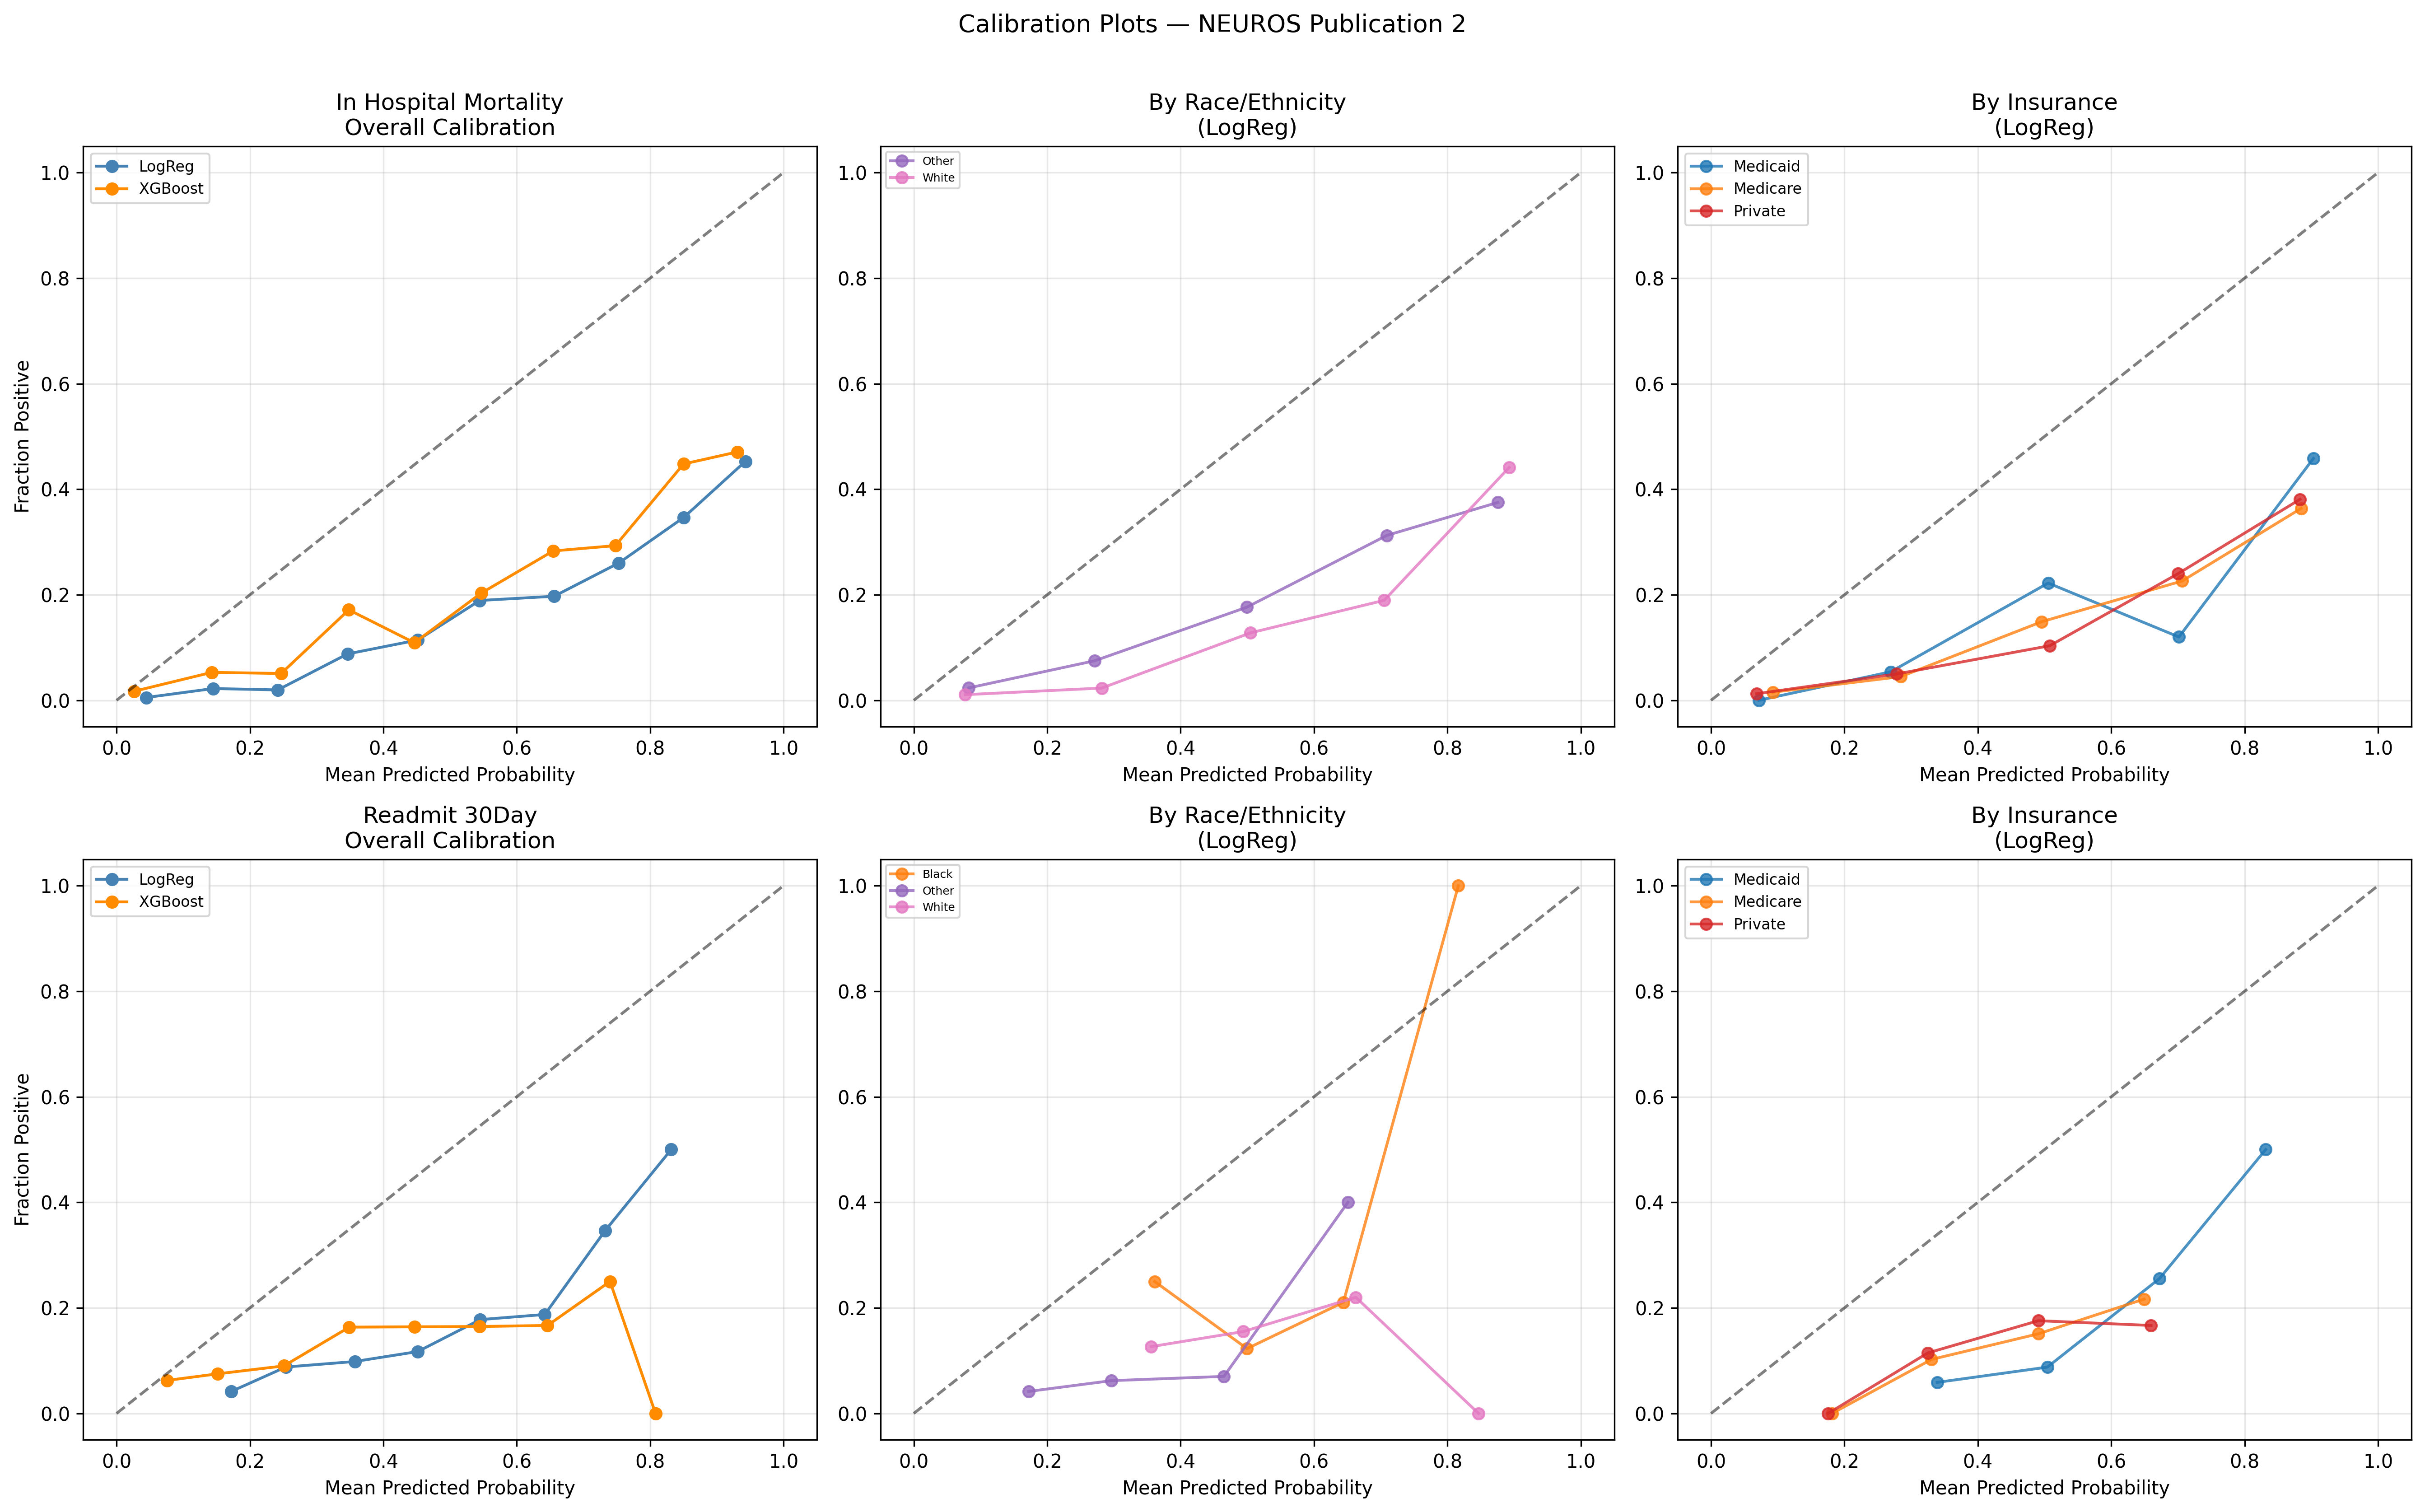

✓ Calibration plots saved.


In [96]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row, outcome in enumerate(OUTCOMES):
    y_te      = MODELS[outcome]['y_te']
    lr_prob   = MODELS[outcome]['lr_prob']
    xgb_prob  = MODELS[outcome]['xgb_prob']
    test_mask = df['split'] == 'test'
    df_test   = df[test_mask].copy().reset_index(drop=True)
    df_test['y_true'] = y_te

    # Overall calibration
    ax = axes[row, 0]
    for prob, label, color in [(lr_prob,'LogReg','steelblue'),
                                (xgb_prob,'XGBoost','darkorange')]:
        fp, mp = calibration_curve(y_te, prob, n_bins=10)
        ax.plot(mp, fp, 'o-', color=color, label=label)
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title(f'{outcome.replace("_"," ").title()}\nOverall Calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction Positive')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # By race
    ax = axes[row, 1]
    df_test['lr_prob'] = lr_prob
    colors = plt.cm.tab10.colors
    for ci, grp in enumerate(sorted(df_test['race_group'].dropna().unique())):
        sub = df_test[df_test['race_group']==grp]
        if sub['y_true'].sum() < MIN_EVENTS or len(sub) < 20:
            continue
        try:
            fp, mp = calibration_curve(sub['y_true'], sub['lr_prob'], n_bins=5)
            ax.plot(mp, fp, 'o-', color=colors[ci % 10], label=grp, alpha=0.8)
        except:
            pass
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title('By Race/Ethnicity\n(LogReg)')
    ax.set_xlabel('Mean Predicted Probability')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)

    # By insurance
    ax = axes[row, 2]
    for ci, grp in enumerate(sorted(df_test['insurance_group'].dropna().unique())):
        sub = df_test[df_test['insurance_group']==grp]
        if sub['y_true'].sum() < MIN_EVENTS or len(sub) < 20:
            continue
        try:
            fp, mp = calibration_curve(sub['y_true'], sub['lr_prob'], n_bins=5)
            ax.plot(mp, fp, 'o-', color=colors[ci % 10], label=grp, alpha=0.8)
        except:
            pass
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title('By Insurance\n(LogReg)')
    ax.set_xlabel('Mean Predicted Probability')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Calibration Plots — NEUROS Publication 2', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT + 'pub2_calibration.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Calibration plots saved.")

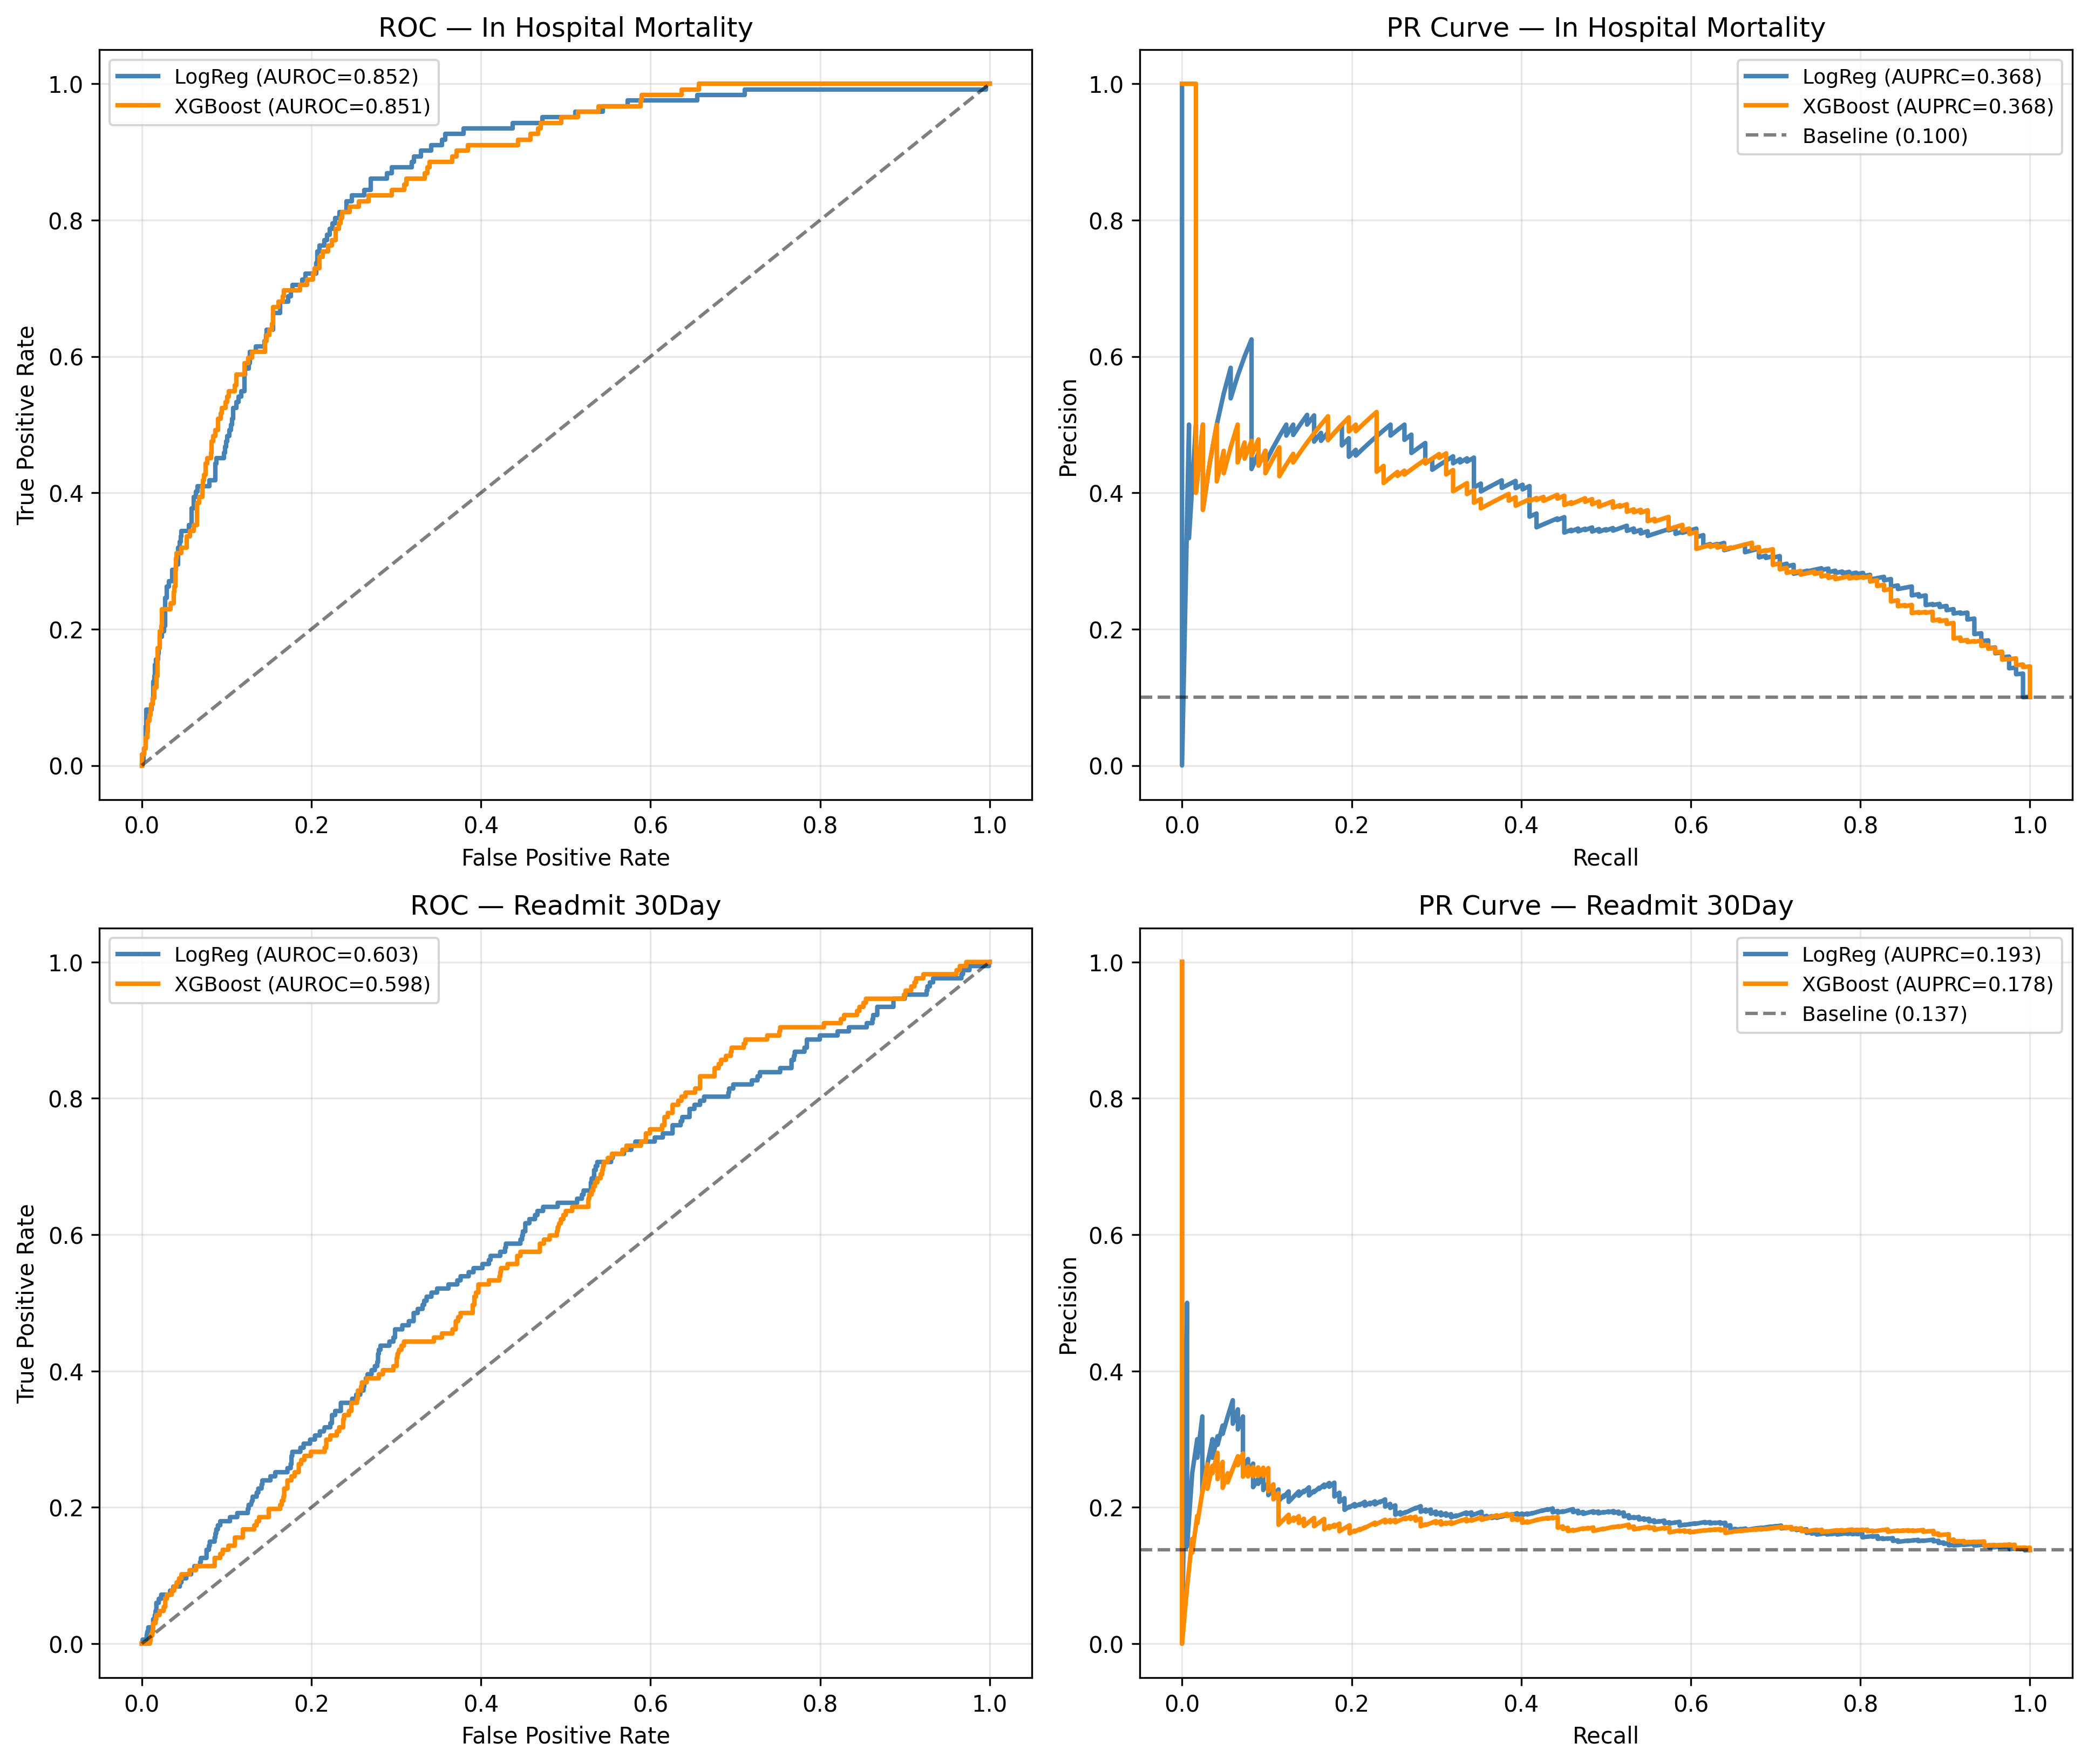

✓ ROC and PR curves saved.


In [97]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for row, outcome in enumerate(OUTCOMES):
    y_te    = MODELS[outcome]['y_te']
    lr_prob = MODELS[outcome]['lr_prob']
    xgb_prob= MODELS[outcome]['xgb_prob']

    # ROC
    ax = axes[row, 0]
    for prob, label, color in [(lr_prob,'LogReg','steelblue'),
                                (xgb_prob,'XGBoost','darkorange')]:
        fpr, tpr, _ = roc_curve(y_te, prob)
        au = roc_auc_score(y_te, prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUROC={au:.3f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {outcome.replace("_"," ").title()}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Precision-Recall
    ax = axes[row, 1]
    for prob, label, color in [(lr_prob,'LogReg','steelblue'),
                                (xgb_prob,'XGBoost','darkorange')]:
        prec, rec, _ = precision_recall_curve(y_te, prob)
        au = average_precision_score(y_te, prob)
        ax.plot(rec, prec, color=color, lw=2, label=f'{label} (AUPRC={au:.3f})')
    baseline = y_te.mean()
    ax.axhline(baseline, color='k', ls='--', alpha=0.5,
               label=f'Baseline ({baseline:.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'PR Curve — {outcome.replace("_"," ").title()}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT + 'pub2_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ ROC and PR curves saved.")

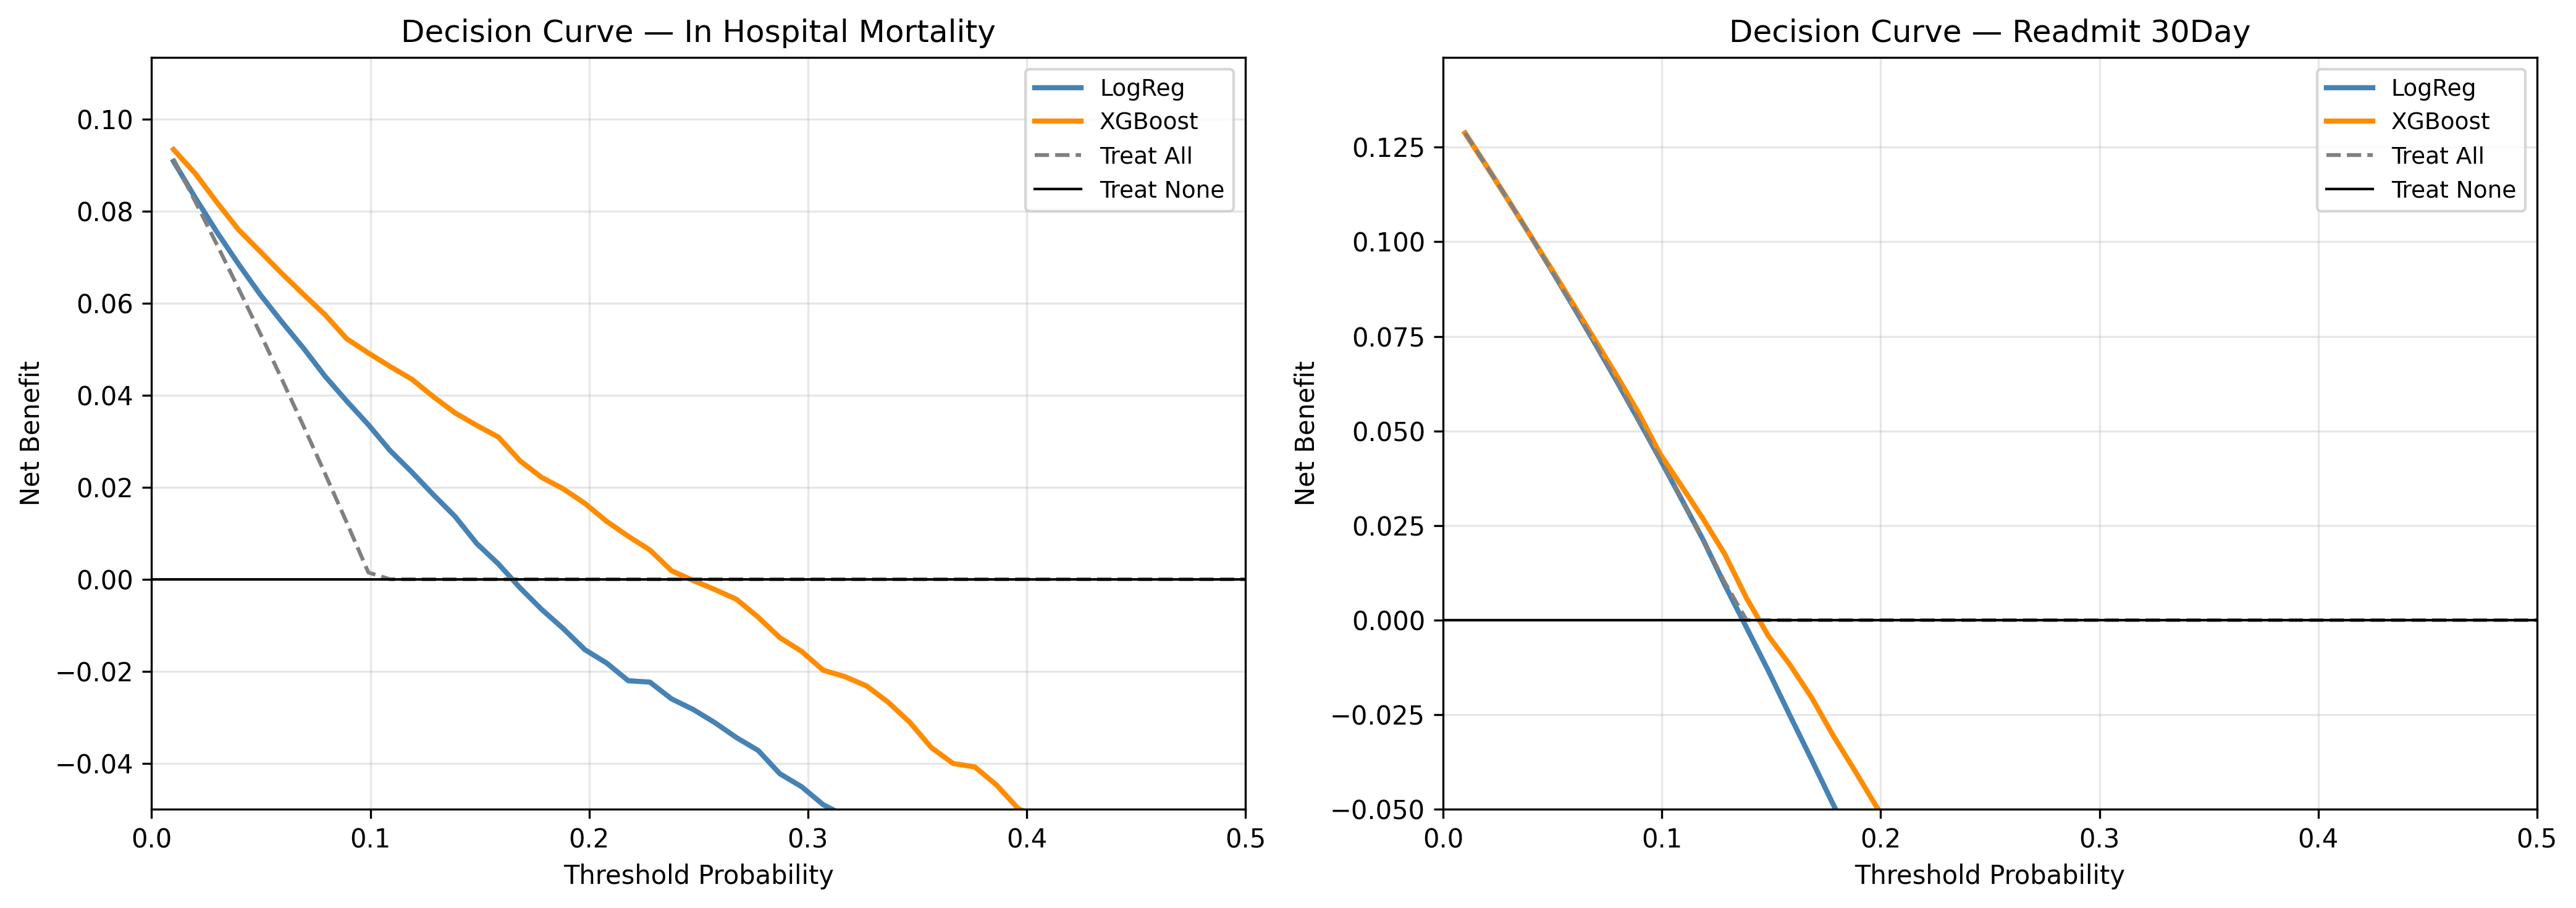

✓ Decision curves saved.


In [98]:
def decision_curve(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)
    n   = len(y_true)
    prev= y_true.mean()
    net_benefit_model = []
    net_benefit_all   = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tp = ((y_pred==1) & (y_true==1)).sum()
        fp = ((y_pred==1) & (y_true==0)).sum()
        nb_model = tp/n - fp/n * (t/(1-t))
        nb_all   = prev - (1-prev)*(t/(1-t))
        net_benefit_model.append(nb_model)
        net_benefit_all.append(max(nb_all, 0))
    return thresholds, np.array(net_benefit_model), np.array(net_benefit_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, outcome in enumerate(OUTCOMES):
    ax      = axes[i]
    y_te    = MODELS[outcome]['y_te']
    lr_prob = MODELS[outcome]['lr_prob']
    xgb_prob= MODELS[outcome]['xgb_prob']

    t, nb_lr,  nb_all = decision_curve(y_te, lr_prob)
    _, nb_xgb, _      = decision_curve(y_te, xgb_prob)

    ax.plot(t, nb_lr,  color='steelblue',   lw=2, label='LogReg')
    ax.plot(t, nb_xgb, color='darkorange',  lw=2, label='XGBoost')
    ax.plot(t, nb_all, color='gray',        lw=1.5, ls='--', label='Treat All')
    ax.axhline(0, color='black', lw=1, ls='-', label='Treat None')
    ax.set_xlim(0, 0.5)
    ax.set_ylim(-0.05, max(nb_lr.max(), nb_xgb.max()) + 0.02)
    ax.set_xlabel('Threshold Probability')
    ax.set_ylabel('Net Benefit')
    ax.set_title(f'Decision Curve — {outcome.replace("_"," ").title()}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT + 'pub2_decision_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Decision curves saved.")

Computing SHAP values (XGBoost)...


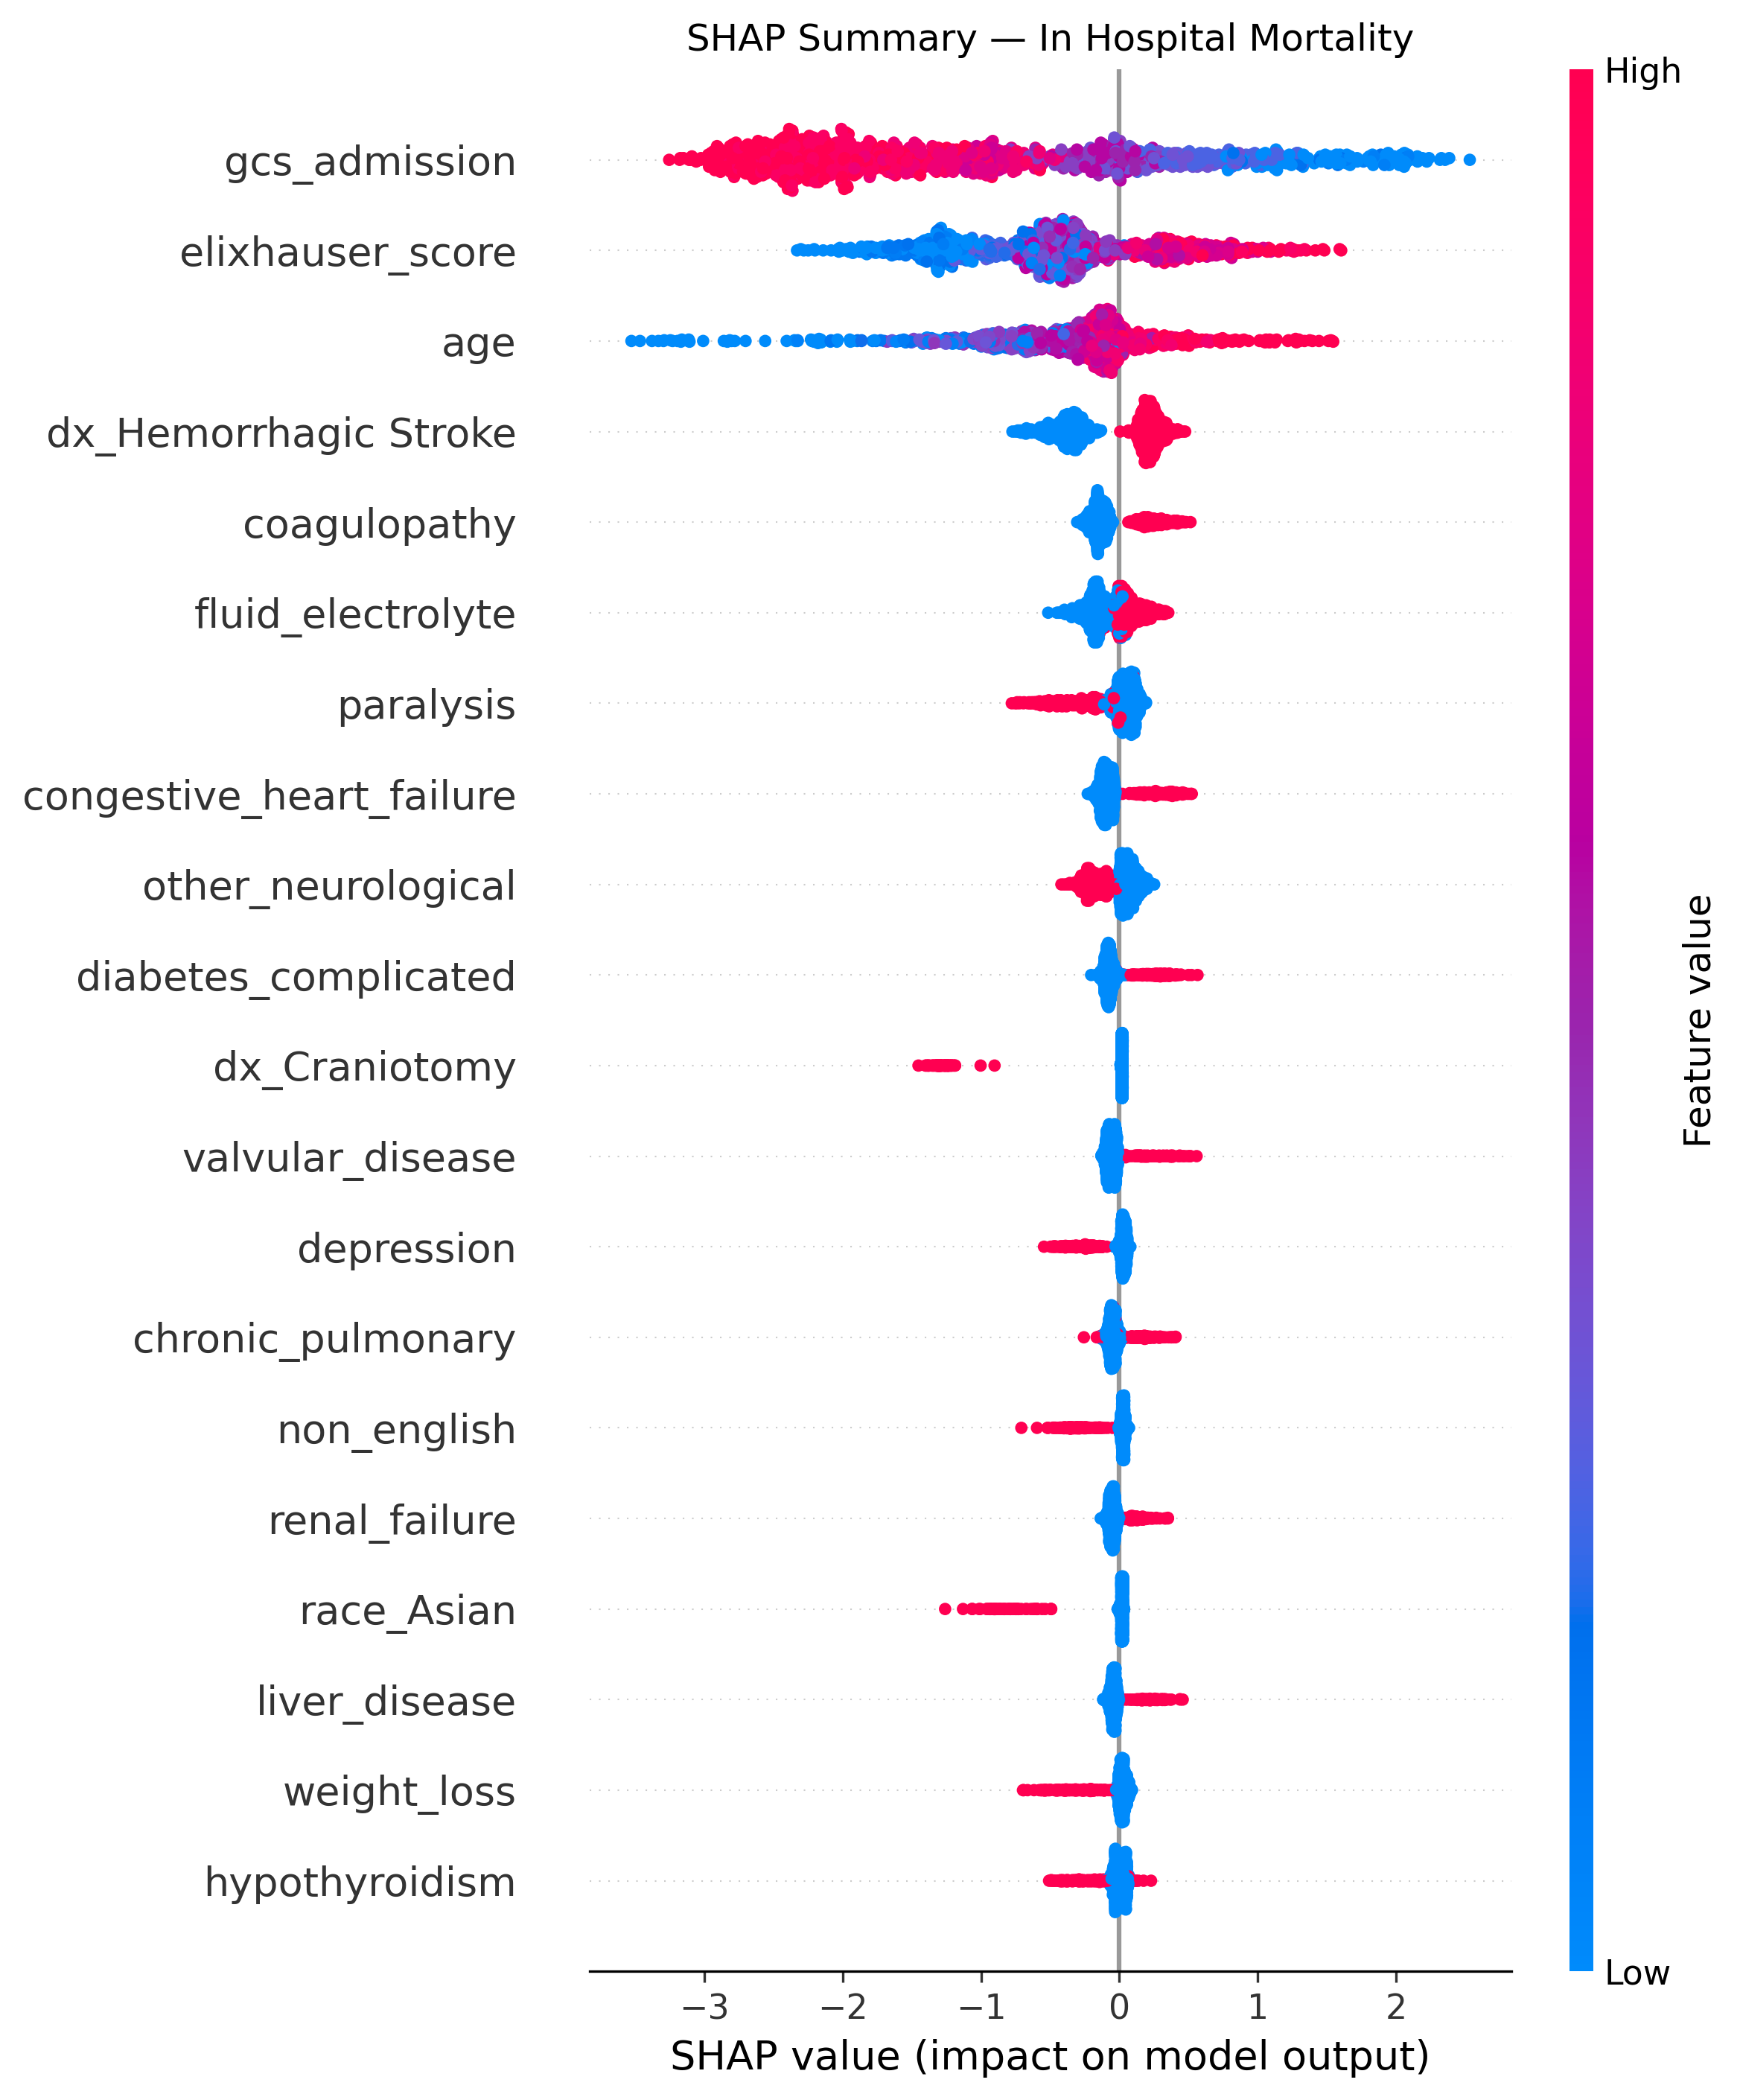


Mean |SHAP| by race — in_hospital_mortality (top 10 features)
  Feature                                    Asian        Black     Hispanic        Other        White
  gcs_admission                             1.5015       1.5237       1.3032       1.3248       1.5292
  elixhauser_score                          0.8386       0.7071       0.6907       0.6412       0.7404
  age                                       0.4503       0.5559       0.6769       0.6889       0.5020
  dx_Hemorrhagic Stroke                     0.3857       0.2942       0.3055       0.3204       0.2937
  coagulopathy                              0.1615       0.1636       0.1727       0.1509       0.1739
  fluid_electrolyte                         0.1277       0.1221       0.1246       0.1013       0.1433
  paralysis                                 0.1177       0.1484       0.1893       0.1430       0.1132
  congestive_heart_failure                  0.1349       0.1126       0.1297       0.1270       0.1167
  other_ne

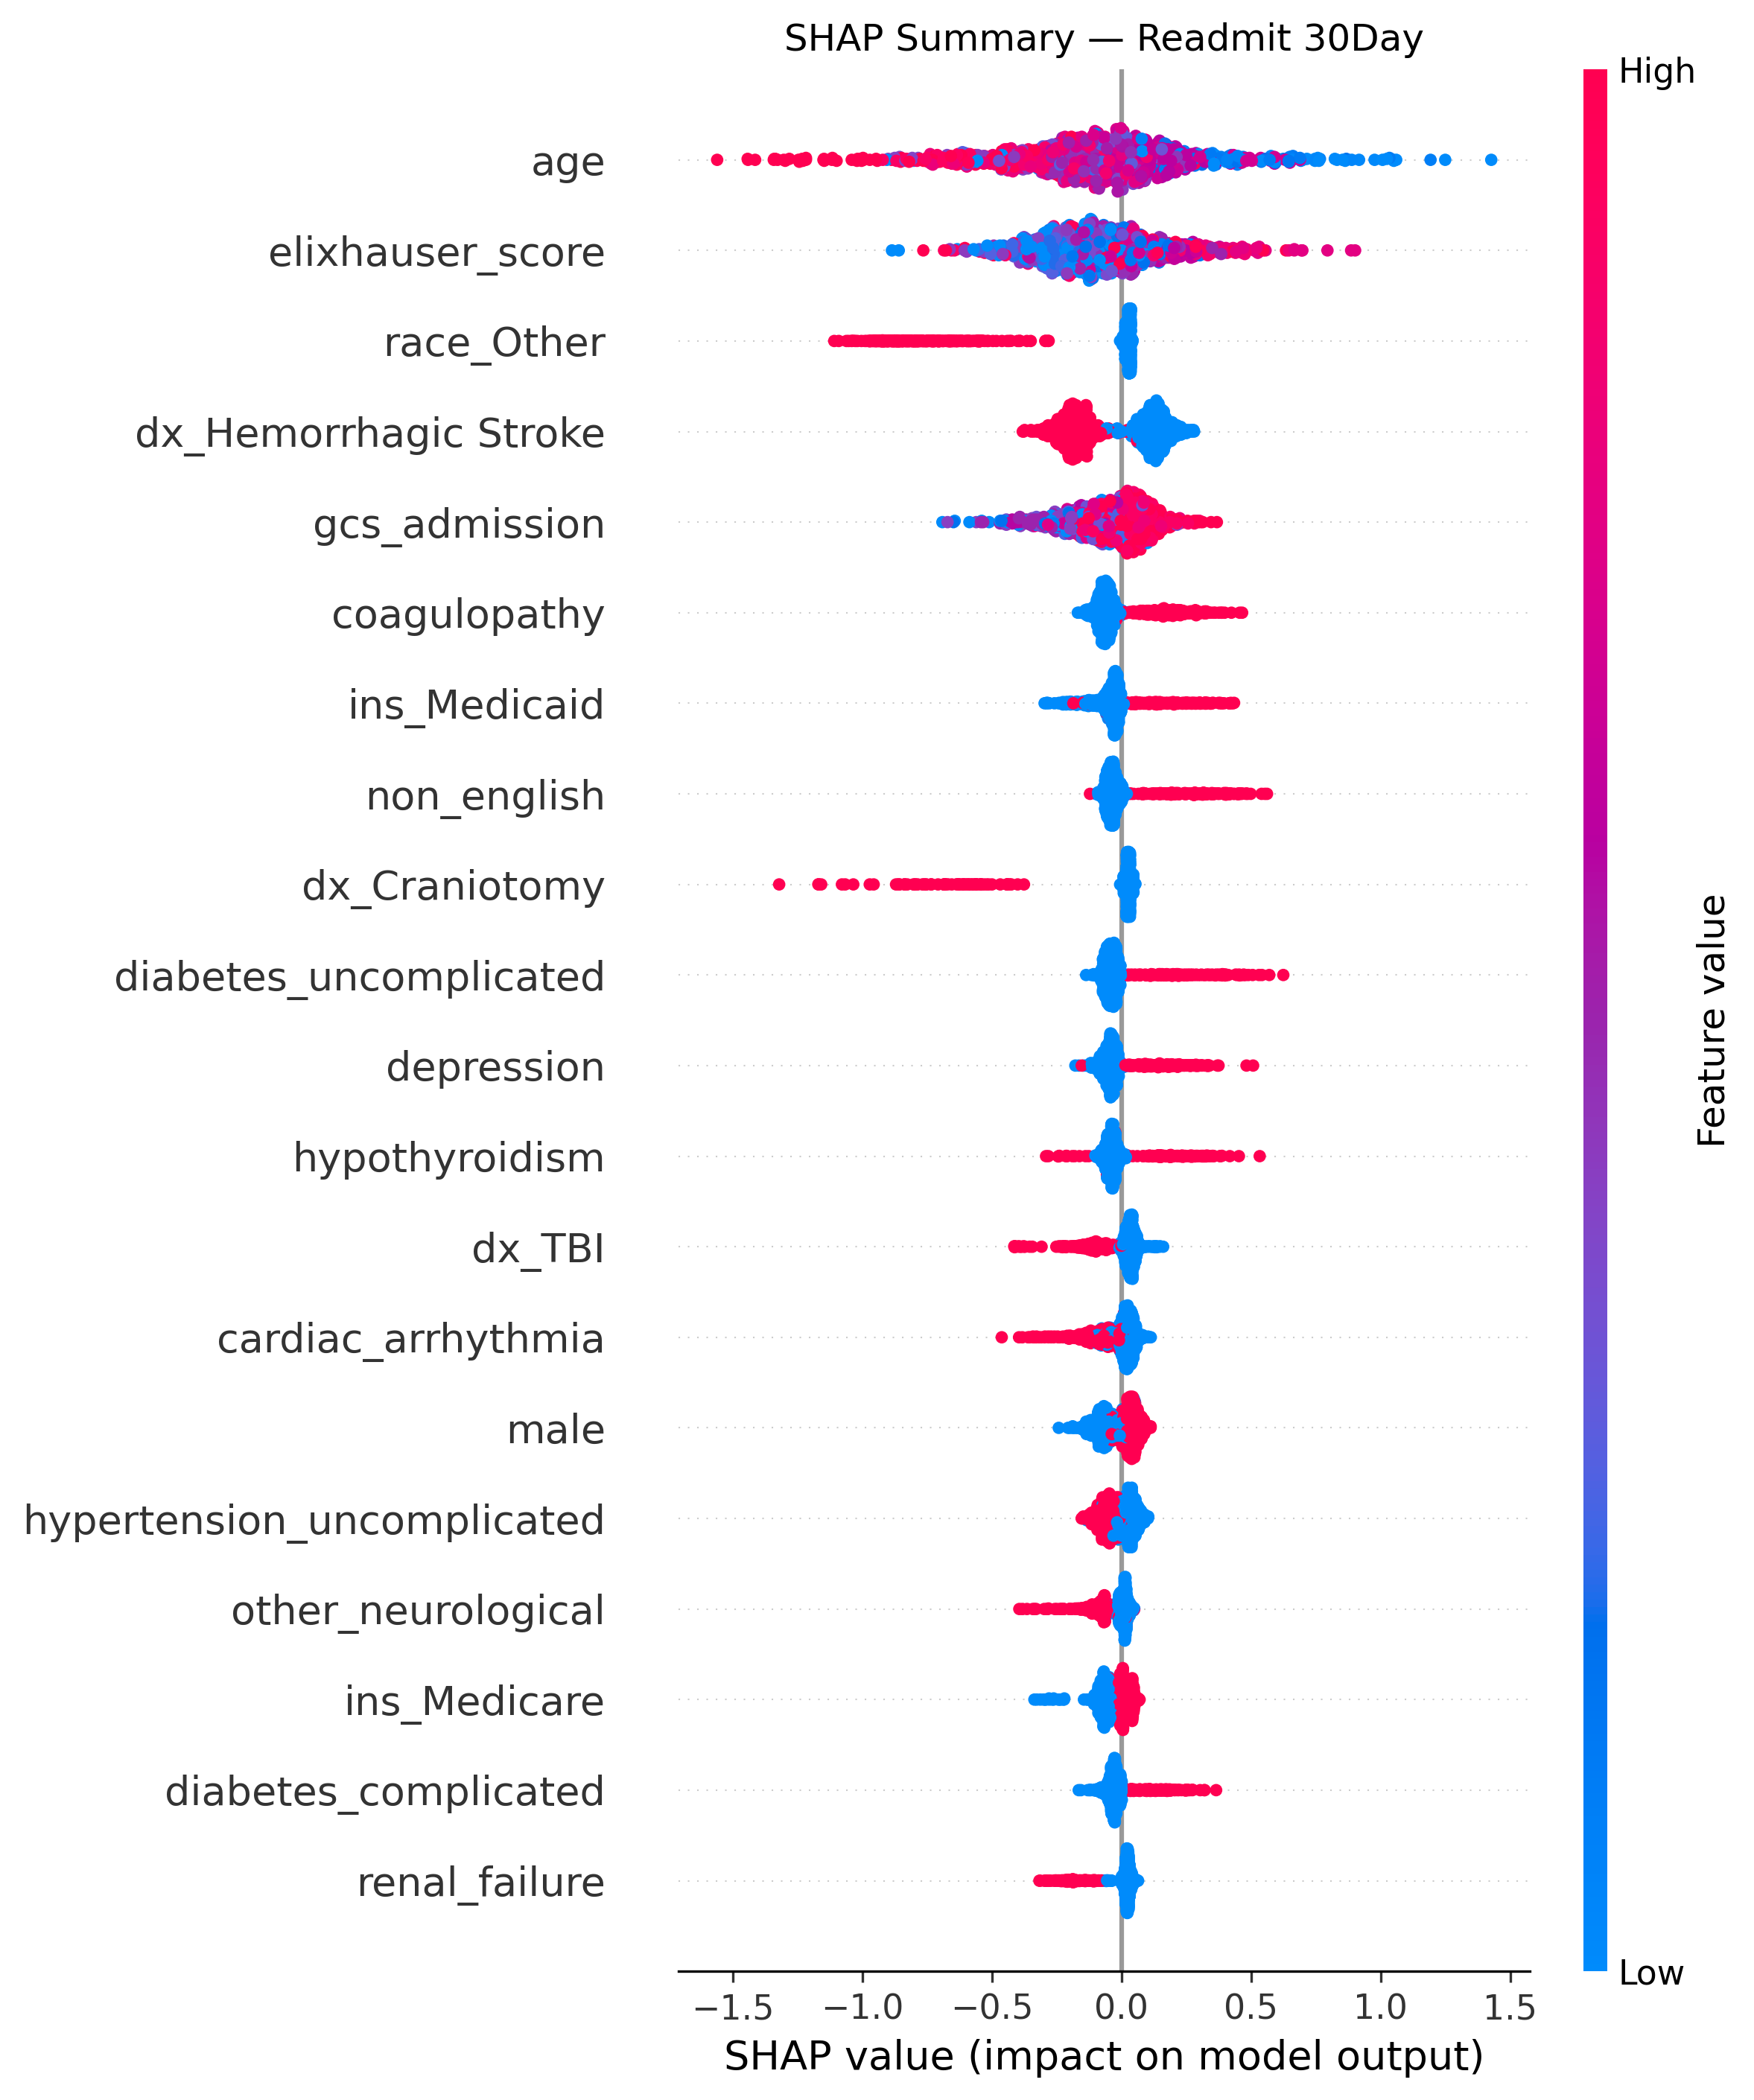


Mean |SHAP| by race — readmit_30day (top 10 features)
  Feature                                    Asian        Black     Hispanic        Other        White
  age                                       0.3047       0.2547       0.2930       0.3146       0.2735
  elixhauser_score                          0.1912       0.2018       0.1756       0.2495       0.1876
  race_Other                                0.0281       0.0272       0.0281       0.7652       0.0252
  dx_Hemorrhagic Stroke                     0.1373       0.1625       0.1457       0.1775       0.1530
  gcs_admission                             0.1499       0.1050       0.1311       0.1253       0.1192
  coagulopathy                              0.0794       0.0820       0.0701       0.1259       0.0816
  ins_Medicaid                              0.0644       0.0774       0.1515       0.0711       0.0640
  non_english                               0.2319       0.0757       0.2105       0.0621       0.0434
  dx_Craniotomy   

In [99]:
print("Computing SHAP values (XGBoost)...")

for outcome in OUTCOMES:
    xgb       = MODELS[outcome]['xgb']
    X_te      = MODELS[outcome]['X_te']
    y_te      = MODELS[outcome]['y_te']
    test_mask = df['split'] == 'test'
    df_test   = df[test_mask].copy().reset_index(drop=True)

    explainer  = shap.TreeExplainer(xgb)
    shap_vals  = explainer.shap_values(X_te)
    shap_df    = pd.DataFrame(shap_vals, columns=FEATURE_COLS)

    # Overall beeswarm
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_te, feature_names=FEATURE_COLS,
                      show=False, max_display=20)
    plt.title(f'SHAP Summary — {outcome.replace("_"," ").title()}')
    plt.tight_layout()
    plt.savefig(OUT + f'pub2_shap_{outcome}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Mean |SHAP| by race subgroup (top 10 features)
    top_feats = shap_df.abs().mean().nlargest(10).index.tolist()
    race_sg   = df_test['race_group'].values
    print(f"\nMean |SHAP| by race — {outcome} (top 10 features)")
    print(f"  {'Feature':<35}", end='')
    races = [r for r in sorted(pd.Series(race_sg).dropna().unique())
             if (race_sg == r).sum() >= 20]
    for r in races:
        print(f" {r[:10]:>12}", end='')
    print()
    for feat in top_feats:
        print(f"  {feat:<35}", end='')
        fidx = FEATURE_COLS.index(feat)
        for r in races:
            mask = race_sg == r
            if mask.sum() < 5:
                print(f" {'—':>12}", end='')
            else:
                print(f" {np.abs(shap_vals[mask, fidx]).mean():>12.4f}", end='')
        print()

print("\n✓ SHAP analysis complete.")

In [100]:
import json
from datetime import datetime

summary = {
    'date'    : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'cohort'  : {'n': int(len(df)), 'train': int((df['split']=='train').sum()),
                 'test': int((df['split']=='test').sum())},
    'results' : {}
}

for outcome in OUTCOMES:
    ci   = BOOT_CI[outcome]
    summary['results'][outcome] = {}
    for mname in ['lr','xgb']:
        pt = RESULTS[outcome][mname]
        b  = ci[mname]
        summary['results'][outcome][mname] = {
            k: {'point': round(pt[k],4),
                'ci_lo': round(float(b.loc[0.025,k]),4),
                'ci_hi': round(float(b.loc[0.975,k]),4)}
            for k in pt
        }

with open(OUT + 'pub2_results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Print final summary table
print("=" * 65)
print("NEUROS PUBLICATION 2 — FINAL RESULTS SUMMARY")
print("=" * 65)
for outcome in OUTCOMES:
    print(f"\n{outcome}")
    print(f"  {'Metric':<10} {'LogReg':>20} {'XGBoost':>20}")
    print(f"  {'-'*52}")
    for k in ['auroc','auprc','brier','sens','spec','ppv','npv']:
        lr_pt  = RESULTS[outcome]['lr'][k]
        xgb_pt = RESULTS[outcome]['xgb'][k]
        lr_lo  = float(BOOT_CI[outcome]['lr'].loc[0.025,k])
        lr_hi  = float(BOOT_CI[outcome]['lr'].loc[0.975,k])
        xgb_lo = float(BOOT_CI[outcome]['xgb'].loc[0.025,k])
        xgb_hi = float(BOOT_CI[outcome]['xgb'].loc[0.975,k])
        lr_str  = f"{lr_pt:.3f} ({lr_lo:.3f}–{lr_hi:.3f})"
        xgb_str = f"{xgb_pt:.3f} ({xgb_lo:.3f}–{xgb_hi:.3f})"
        print(f"  {k:<10} {lr_str:>20} {xgb_str:>20}")

print(f"\n✓ All outputs saved to: {OUT}")
print("Files saved:")
for fname in ['pub2_coef_table_in_hospital_mortality.csv',
              'pub2_coef_table_readmit_30day.csv',
              'pub2_subgroup_performance.csv',
              'pub2_fairness_audit.csv',
              'pub2_raceblind_sensitivity.csv',
              'pub2_calibration.png',
              'pub2_roc_pr_curves.png',
              'pub2_decision_curves.png',
              'pub2_shap_in_hospital_mortality.png',
              'pub2_shap_readmit_30day.png',
              'pub2_results_summary.json']:
    print(f"  • {fname}")

NEUROS PUBLICATION 2 — FINAL RESULTS SUMMARY

in_hospital_mortality
  Metric                   LogReg              XGBoost
  ----------------------------------------------------
  auroc       0.852 (0.816–0.882)  0.851 (0.821–0.880)
  auprc       0.368 (0.290–0.463)  0.368 (0.298–0.458)
  brier       0.156 (0.143–0.168)  0.118 (0.106–0.129)
  sens        0.795 (0.722–0.864)  0.680 (0.600–0.759)
  spec        0.772 (0.747–0.796)  0.839 (0.818–0.861)
  ppv         0.280 (0.235–0.327)  0.320 (0.265–0.379)
  npv         0.971 (0.959–0.982)  0.959 (0.946–0.970)

readmit_30day
  Metric                   LogReg              XGBoost
  ----------------------------------------------------
  auroc       0.603 (0.558–0.648)  0.598 (0.553–0.643)
  auprc       0.193 (0.157–0.247)  0.178 (0.145–0.221)
  brier       0.227 (0.222–0.234)  0.186 (0.177–0.194)
  sens        0.521 (0.449–0.597)  0.281 (0.210–0.353)
  spec        0.649 (0.620–0.676)  0.786 (0.760–0.811)
  ppv         0.191 (0.155–0.228)  0.

In [101]:
# ── Model card ───────────────────────────────────────────────────────────────
# Required by scoping review Table 3 (transparency domain).
# Documents intended use, known failure modes, and subgroup limitations
# before any clinical deployment claim.

from datetime import datetime

model_card = f"""
NEUROS MODEL CARD
=================
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Publication: "Development, Validation, and Fairness Audit of a Neurosurgical
             ICU Outcome Prediction Model Using MIMIC-IV" (Publication 2)

─────────────────────────────────────────────────────────────────────────────
INTENDED USE
─────────────────────────────────────────────────────────────────────────────
Target population : Adult neurosurgical ICU admissions (age ≥18) following
                    TBI, hemorrhagic stroke, surgically treated ischemic
                    stroke, craniotomy, brain tumor, or spine surgery.
Prediction time   : At ICU admission, using admission-available variables.
Prediction horizon: In-hospital mortality; 30-day readmission among survivors.
Intended users    : Researchers; clinical informatics teams evaluating equity
                    of risk stratification tools.
Intended action   : Research and audit purposes only. Not validated for
                    real-time clinical decision support.

─────────────────────────────────────────────────────────────────────────────
PROHIBITED USES
─────────────────────────────────────────────────────────────────────────────
- Do not use to guide individual triage, treatment limitation, or discharge
  decisions without prospective clinical validation.
- Do not apply to pediatric patients (age <18).
- Do not apply outside neurosurgical ICU settings.
- Do not use as a substitute for clinical judgment.
- Do not deploy at institutions without revalidation on local data.

─────────────────────────────────────────────────────────────────────────────
DATA PROVENANCE
─────────────────────────────────────────────────────────────────────────────
Source            : MIMIC-IV v3.0 (Beth Israel Deaconess Medical Center,
                    Boston MA; 2008–2022; single academic medical center).
Cohort            : {len(df):,} admissions from {df['subject_id'].nunique():,} unique patients.
Train / Test split: Temporal — train 2008–2016, test 2017–2022.
Known limitations : Single-center; academic referral center demographics
                    may not generalise to community or safety-net hospitals.

─────────────────────────────────────────────────────────────────────────────
SUBGROUP LIMITATIONS AND KNOWN FAILURE MODES
─────────────────────────────────────────────────────────────────────────────
- Native American/Alaska Native (n=9) and Pacific Islander (n=12):
  too small for stable fairness estimates. Fairness metrics suppressed.
  These groups cannot be assumed to have equitable model performance.
- Readmission model pseudo-R²=0.027 (inherited from 1a) — low explanatory
  power; readmission predictions should be interpreted with caution.
- Race-blind vs race-aware AUROC difference is small; however, calibration
  gaps by subgroup persist and should not be ignored.
- Model trained on single-center data. Demographic composition, referral
  patterns, and documentation practices at BIDMC may differ from other
  institutions, limiting generalisability.
- Fairness drift over time not prospectively monitored (see Davis et al
  2025 cited in Publication 1b for rationale on monitoring requirement).

─────────────────────────────────────────────────────────────────────────────
PERFORMANCE SUMMARY (TEST SET, 95% BOOTSTRAP CI)
─────────────────────────────────────────────────────────────────────────────"""

for outcome in OUTCOMES:
    model_card += f"\n{outcome}:\n"
    for mname in ['lr','xgb']:
        pt = RESULTS[outcome][mname]
        ci = BOOT_CI[outcome][mname]
        model_card += f"  {mname.upper():<8}"
        for k in ['auroc','brier','sens','ppv']:
            lo = float(ci.loc[0.025,k])
            hi = float(ci.loc[0.975,k])
            model_card += f"  {k}={pt[k]:.3f}({lo:.3f}-{hi:.3f})"
        model_card += "\n"

model_card += f"""
─────────────────────────────────────────────────────────────────────────────
FAIRNESS SUMMARY
─────────────────────────────────────────────────────────────────────────────
Primary fairness metric : Equal opportunity difference (EOD) vs reference
                          group (White race; Private insurance).
Suppression rule        : Subgroups with <{MIN_EVENTS} outcome events not reported.
Intersectional analysis : Race × insurance (prespecified; exploratory).
Race-blind sensitivity  : Logistic regression refit without race/insurance
                          dummies; AUROC and calibration gaps compared.

─────────────────────────────────────────────────────────────────────────────
TRANSPARENCY AND REPRODUCIBILITY
─────────────────────────────────────────────────────────────────────────────
Code          : Available in NEUROS Publication 2 Colab notebook.
Data          : MIMIC-IV v3.0 via PhysioNet (credentialed access required).
Model version : v1.0 — {datetime.now().strftime('%Y-%m-%d')}
Retirement criteria : Retrain if overall AUROC drops >0.05 or subgroup EOD
                      exceeds 0.10 on any group with ≥{MIN_EVENTS} events in new data.
─────────────────────────────────────────────────────────────────────────────
"""

print(model_card)

with open(OUT + 'pub2_model_card.txt', 'w') as f:
    f.write(model_card)

print("✓ Model card saved to pub2_model_card.txt")


NEUROS MODEL CARD
Generated: 2026-07-16 03:19
Publication: "Development, Validation, and Fairness Audit of a Neurosurgical
             ICU Outcome Prediction Model Using MIMIC-IV" (Publication 2)

─────────────────────────────────────────────────────────────────────────────
INTENDED USE
─────────────────────────────────────────────────────────────────────────────
Target population : Adult neurosurgical ICU admissions (age ≥18) following
                    TBI, hemorrhagic stroke, surgically treated ischemic
                    stroke, craniotomy, brain tumor, or spine surgery.
Prediction time   : At ICU admission, using admission-available variables.
Prediction horizon: In-hospital mortality; 30-day readmission among survivors.
Intended users    : Researchers; clinical informatics teams evaluating equity
                    of risk stratification tools.
Intended action   : Research and audit purposes only. Not validated for
                    real-time clinical decision support.

─

# NEUROS Publication 3 — Debiasing Experiments

Builds directly on the Publication 2 pipeline above (run all cells above this point first, in order). Targets the two readmission fairness gaps identified in Pub 2's audit:

- **Medicaid** insurance: EOD = +0.444 (over-predicts readmission relative to Private)
- **Other race**: EOD = -0.294 (misses readmissions relative to White)

Mortality is excluded — its fairness gaps already cross zero, so debiasing isn't warranted there.

Three methods are run and compared against the untouched Pub 2 logistic regression baseline: reweighting, SMOTENC-based resampling, and fairlearn's exponentiated-gradient reduction under an equalized-odds constraint. Requires `imbalanced-learn` and `fairlearn` (see `requirements.txt`).

In [ ]:
# ── SECTION 17: PUB 3 CONFIG — DEBIASING TARGETS ─────────────────────────────
from imblearn.over_sampling import SMOTENC
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

print('=' * 70)
print('PUBLICATION 3 — DEBIASING EXPERIMENTS')
print('Objective: narrow the two readmission fairness gaps from Pub 2 without')
print('materially sacrificing overall discrimination (AUROC).')
print('=' * 70)

TARGET_OUTCOME = 'readmit_30day'   # mortality gaps already cross zero
REWEIGHT_FACTOR = 2.0              # extra upweighting for target-group training rows
AUROC_TOLERANCE = 0.01             # max acceptable AUROC drop vs baseline to call a method viable

test_mask  = df['split'] == 'test'
train_mask = df['split'] == 'train'
df_train   = df[train_mask].copy().reset_index(drop=True)
df_test    = df[test_mask].copy().reset_index(drop=True)

y_tr   = MODELS[TARGET_OUTCOME]['y_tr']
y_te   = MODELS[TARGET_OUTCOME]['y_te']
X_tr   = MODELS[TARGET_OUTCOME]['X_tr']
X_te   = MODELS[TARGET_OUTCOME]['X_te']
X_tr_s = MODELS[TARGET_OUTCOME]['X_tr_s']
X_te_s = MODELS[TARGET_OUTCOME]['X_te_s']
df_test['y_true'] = y_te

medicaid_train      = (df_train['insurance_group'] == 'Medicaid').values
other_race_train    = (df_train['race_group'] == 'Other').values
target_group_train  = medicaid_train | other_race_train

print(f'\nTraining rows in target groups: {target_group_train.sum():,} ({target_group_train.mean()*100:.1f}% of {len(target_group_train):,})')
print(f'  Medicaid  : {medicaid_train.sum():,}')
print(f'  Other race: {other_race_train.sum():,}')

def compute_eod(prob_col, group_col, group_val, ref_col, ref_val):
    sub = df_test[df_test[group_col] == group_val]
    ref = df_test[df_test[ref_col] == ref_val]
    return fairness_metrics(sub, ref, prob_col=prob_col)['eod']

def bootstrap_eod(prob_col, group_col, group_val, ref_col, ref_val, n_boot=500):
    sub = df_test[df_test[group_col] == group_val]
    ref = df_test[df_test[ref_col] == ref_val]
    vals = []
    for _ in range(n_boot):
        si = resample(np.arange(len(sub)), replace=True)
        ri = resample(np.arange(len(ref)), replace=True)
        sb, rb = sub.iloc[si], ref.iloc[ri]
        if sb['y_true'].sum() < 3 or rb['y_true'].sum() < 3:
            continue
        try:
            vals.append(fairness_metrics(sb, rb, prob_col=prob_col)['eod'])
        except Exception:
            pass
    if not vals:
        return np.nan, np.nan
    lo, hi = np.quantile(vals, [0.025, 0.975])
    return lo, hi

DEBIAS_RESULTS = {}

In [ ]:
# ── SECTION 18: BASELINE (FROM PUB 2, NO DEBIASING) ──────────────────────────
print('=' * 70)
print(f'BASELINE — {TARGET_OUTCOME} (Pub 2 logistic regression, no debiasing)')
print('=' * 70)

baseline_prob = MODELS[TARGET_OUTCOME]['lr_prob']
df_test['baseline_prob'] = baseline_prob

baseline_auroc = roc_auc_score(y_te, baseline_prob)
baseline_brier = brier_score_loss(y_te, baseline_prob)
baseline_medicaid_eod = compute_eod('baseline_prob', 'insurance_group', 'Medicaid', 'insurance_group', 'Private')
baseline_other_eod    = compute_eod('baseline_prob', 'race_group', 'Other', 'race_group', 'White')

print(f'AUROC          : {baseline_auroc:.3f}')
print(f'Brier          : {baseline_brier:.3f}')
print(f'Medicaid EOD   : {baseline_medicaid_eod:+.3f}  (target: narrow toward 0 from +0.444)')
print(f'Other race EOD : {baseline_other_eod:+.3f}  (target: narrow toward 0 from -0.294)')

DEBIAS_RESULTS['Baseline'] = {
    'auroc': baseline_auroc, 'brier': baseline_brier,
    'medicaid_eod': baseline_medicaid_eod, 'other_race_eod': baseline_other_eod,
    'prob_col': 'baseline_prob'
}

In [ ]:
# ── SECTION 19: METHOD 1 — REWEIGHTING ───────────────────────────────────────
print('=' * 70)
print('METHOD 1: REWEIGHTING')
print('=' * 70)

class_counts = np.bincount(y_tr)
class_weight_vec = len(y_tr) / (2 * class_counts[y_tr])   # replicates class_weight='balanced'
group_weight_vec = np.where(target_group_train, REWEIGHT_FACTOR, 1.0)
sample_weight_reweighted = class_weight_vec * group_weight_vec

lr_reweighted = LogisticRegression(max_iter=2000, random_state=42, C=1.0)
lr_reweighted.fit(X_tr_s, y_tr, sample_weight=sample_weight_reweighted)
reweighted_prob = lr_reweighted.predict_proba(X_te_s)[:, 1]
df_test['reweighted_prob'] = reweighted_prob

reweighted_auroc = roc_auc_score(y_te, reweighted_prob)
reweighted_brier = brier_score_loss(y_te, reweighted_prob)
reweighted_medicaid_eod = compute_eod('reweighted_prob', 'insurance_group', 'Medicaid', 'insurance_group', 'Private')
reweighted_other_eod    = compute_eod('reweighted_prob', 'race_group', 'Other', 'race_group', 'White')

print(f'AUROC          : {reweighted_auroc:.3f}  (baseline {baseline_auroc:.3f})')
print(f'Brier          : {reweighted_brier:.3f}  (baseline {baseline_brier:.3f})')
print(f'Medicaid EOD   : {reweighted_medicaid_eod:+.3f}  (baseline {baseline_medicaid_eod:+.3f})')
print(f'Other race EOD : {reweighted_other_eod:+.3f}  (baseline {baseline_other_eod:+.3f})')

DEBIAS_RESULTS['Reweighting'] = {
    'auroc': reweighted_auroc, 'brier': reweighted_brier,
    'medicaid_eod': reweighted_medicaid_eod, 'other_race_eod': reweighted_other_eod,
    'prob_col': 'reweighted_prob'
}

In [ ]:
# ── SECTION 20: METHOD 2 — RESAMPLING (SMOTENC, target-subgroup oversampling) ─
print('=' * 70)
print('METHOD 2: RESAMPLING (SMOTENC)')
print('=' * 70)

CONTINUOUS_FEATS = {'age', 'elixhauser_score', 'gcs_admission', 'sofa_score'}
categorical_idx = [i for i, c in enumerate(FEATURE_COLS) if c not in CONTINUOUS_FEATS]

X_tr_df = pd.DataFrame(X_tr, columns=FEATURE_COLS)
y_tr_series = pd.Series(y_tr)

target_idx = np.where(target_group_train)[0]
other_idx  = np.where(~target_group_train)[0]

X_target, y_target = X_tr_df.iloc[target_idx], y_tr_series.iloc[target_idx]
X_other,  y_other  = X_tr_df.iloc[other_idx],  y_tr_series.iloc[other_idx]

target_pos_rate = y_target.mean()
other_pos_rate  = y_other.mean()
print(f'Readmission rate — target groups: {target_pos_rate*100:.1f}%  |  other groups: {other_pos_rate*100:.1f}%')

n_target_pos    = int(y_target.sum())
n_target_needed = max(int(round(other_pos_rate * len(y_target))), n_target_pos + 1)
k_neighbors     = min(5, max(1, n_target_pos - 1))

smote_nc = SMOTENC(categorical_features=categorical_idx, random_state=42,
                    sampling_strategy={1: n_target_needed}, k_neighbors=k_neighbors)
X_target_res, y_target_res = smote_nc.fit_resample(X_target, y_target)

X_tr_resampled = pd.concat([X_target_res, X_other], axis=0).reset_index(drop=True)
y_tr_resampled = pd.concat([y_target_res, y_other], axis=0).reset_index(drop=True).values

print(f'Training set size: {len(y_tr):,} -> {len(y_tr_resampled):,} after resampling')
print(f'Overall readmission rate: {y_tr.mean()*100:.1f}% -> {y_tr_resampled.mean()*100:.1f}%')

scaler_resampled = StandardScaler()
X_tr_resampled_s = scaler_resampled.fit_transform(X_tr_resampled.values)
X_te_resampled_s = scaler_resampled.transform(X_te)

lr_resampled = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced', C=1.0)
lr_resampled.fit(X_tr_resampled_s, y_tr_resampled)
resampled_prob = lr_resampled.predict_proba(X_te_resampled_s)[:, 1]
df_test['resampled_prob'] = resampled_prob

resampled_auroc = roc_auc_score(y_te, resampled_prob)
resampled_brier = brier_score_loss(y_te, resampled_prob)
resampled_medicaid_eod = compute_eod('resampled_prob', 'insurance_group', 'Medicaid', 'insurance_group', 'Private')
resampled_other_eod    = compute_eod('resampled_prob', 'race_group', 'Other', 'race_group', 'White')

print(f'\nAUROC          : {resampled_auroc:.3f}  (baseline {baseline_auroc:.3f})')
print(f'Brier          : {resampled_brier:.3f}  (baseline {baseline_brier:.3f})')
print(f'Medicaid EOD   : {resampled_medicaid_eod:+.3f}  (baseline {baseline_medicaid_eod:+.3f})')
print(f'Other race EOD : {resampled_other_eod:+.3f}  (baseline {baseline_other_eod:+.3f})')

DEBIAS_RESULTS['Resampling'] = {
    'auroc': resampled_auroc, 'brier': resampled_brier,
    'medicaid_eod': resampled_medicaid_eod, 'other_race_eod': resampled_other_eod,
    'prob_col': 'resampled_prob'
}

In [ ]:
# ── SECTION 21: METHOD 3 — FAIRNESS-CONSTRAINED OPTIMIZATION (fairlearn) ─────
print('=' * 70)
print('METHOD 3: FAIRNESS-CONSTRAINED OPTIMIZATION (Exponentiated Gradient)')
print('=' * 70)

sensitive_train = df_train[['race_group', 'insurance_group']].reset_index(drop=True)

base_lr    = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced', C=1.0)
constraint = EqualizedOdds()
mitigator  = ExponentiatedGradient(base_lr, constraints=constraint, max_iter=50)
mitigator.fit(X_tr_s, y_tr, sensitive_features=sensitive_train)

def mixture_predict_proba(fitted_mitigator, X):
    probs = np.zeros(X.shape[0])
    for weight, estimator in zip(fitted_mitigator.weights_, fitted_mitigator.predictors_):
        if weight > 0:
            probs += weight * estimator.predict_proba(X)[:, 1]
    return probs

constrained_prob = mixture_predict_proba(mitigator, X_te_s)
df_test['constrained_prob'] = constrained_prob

constrained_auroc = roc_auc_score(y_te, constrained_prob)
constrained_brier = brier_score_loss(y_te, constrained_prob)
constrained_medicaid_eod = compute_eod('constrained_prob', 'insurance_group', 'Medicaid', 'insurance_group', 'Private')
constrained_other_eod    = compute_eod('constrained_prob', 'race_group', 'Other', 'race_group', 'White')

print(f'AUROC          : {constrained_auroc:.3f}  (baseline {baseline_auroc:.3f})')
print(f'Brier          : {constrained_brier:.3f}  (baseline {baseline_brier:.3f})')
print(f'Medicaid EOD   : {constrained_medicaid_eod:+.3f}  (baseline {baseline_medicaid_eod:+.3f})')
print(f'Other race EOD : {constrained_other_eod:+.3f}  (baseline {baseline_other_eod:+.3f})')

DEBIAS_RESULTS['Fairness-Constrained'] = {
    'auroc': constrained_auroc, 'brier': constrained_brier,
    'medicaid_eod': constrained_medicaid_eod, 'other_race_eod': constrained_other_eod,
    'prob_col': 'constrained_prob'
}

In [ ]:
# ── SECTION 22: COMPARISON TABLE ─────────────────────────────────────────────
print('=' * 70)
print('PUB 3 SUMMARY — DEBIASING METHOD COMPARISON')
print('=' * 70)

comparison_rows = []
for method, res in DEBIAS_RESULTS.items():
    prob_col = res['prob_col']
    med_lo, med_hi = bootstrap_eod(prob_col, 'insurance_group', 'Medicaid', 'insurance_group', 'Private')
    oth_lo, oth_hi = bootstrap_eod(prob_col, 'race_group', 'Other', 'race_group', 'White')
    comparison_rows.append({
        'method': method,
        'auroc': res['auroc'],
        'brier': res['brier'],
        'medicaid_eod': res['medicaid_eod'],
        'medicaid_eod_ci_lo': med_lo, 'medicaid_eod_ci_hi': med_hi,
        'other_race_eod': res['other_race_eod'],
        'other_race_eod_ci_lo': oth_lo, 'other_race_eod_ci_hi': oth_hi,
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(OUT, 'pub3_debiasing_comparison.csv'), index=False)
print('\n✓ Comparison table saved: pub3_debiasing_comparison.csv')

In [ ]:
# ── SECTION 23: PLOTS ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
methods = list(DEBIAS_RESULTS.keys())
medicaid_vals = [DEBIAS_RESULTS[m]['medicaid_eod'] for m in methods]
other_vals    = [DEBIAS_RESULTS[m]['other_race_eod'] for m in methods]

axes[0].bar(methods, medicaid_vals, color='steelblue')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Medicaid Readmission EOD by Method')
axes[0].set_ylabel('EOD vs Private insurance')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3)

axes[1].bar(methods, other_vals, color='darkorange')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Other-Race Readmission EOD by Method')
axes[1].set_ylabel('EOD vs White')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'pub3_eod_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10.colors
for ax, (group_col, group_val) in zip(axes, [('insurance_group', 'Medicaid'), ('race_group', 'Other')]):
    sub = df_test[df_test[group_col] == group_val]
    for ci, (method, res) in enumerate(DEBIAS_RESULTS.items()):
        prob_col = res['prob_col']
        if sub['y_true'].sum() < MIN_EVENTS:
            continue
        fp, mp = calibration_curve(sub['y_true'], sub[prob_col], n_bins=5)
        ax.plot(mp, fp, 'o-', color=colors[ci % 10], label=method, alpha=0.8)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f'Calibration — {group_val}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction Positive')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'pub3_calibration_by_method.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✓ Plots saved.')

In [ ]:
# ── SECTION 24: FINAL SUMMARY ─────────────────────────────────────────────────
print('=' * 70)
print('NEUROS PUBLICATION 3 — DEBIASING RESULTS SUMMARY')
print('=' * 70)
print(comparison_df.to_string(index=False))

best = None
for method, res in DEBIAS_RESULTS.items():
    if method == 'Baseline':
        continue
    auroc_drop = baseline_auroc - res['auroc']
    narrows_medicaid = abs(res['medicaid_eod']) < abs(baseline_medicaid_eod)
    narrows_other    = abs(res['other_race_eod']) < abs(baseline_other_eod)
    viable = auroc_drop <= AUROC_TOLERANCE and narrows_medicaid and narrows_other
    flag = '<- VIABLE' if viable else ''
    print(f'\n{method}: AUROC drop={auroc_drop:+.3f}  Medicaid narrows={narrows_medicaid}  Other narrows={narrows_other}  {flag}')
    if viable and (best is None or auroc_drop < best[1]):
        best = (method, auroc_drop)

if best:
    print(f'\n-> Recommended method: {best[0]} (narrows both gaps, AUROC drop {best[1]:+.3f} <= {AUROC_TOLERANCE} tolerance)')
else:
    print(f'\n-> No method narrowed both gaps within the {AUROC_TOLERANCE} AUROC tolerance -- review individual trade-offs in the comparison table above.')

print(f'\n✓ All Pub 3 outputs saved to: {OUT}')